<h1><b>
IAU_B Semester project
</b></h1>

<h3>
Objective:
Predict oxygen saturation variable - <b>oximetry</b>
</h3>

# Project Work Distribution Report

<h2> Team members </h2>

- Bei Veronika

- Michael Chepara


<h2> Work Distribution</h2>

  <h3>--Phase 1---</h3>

  Bei Veronika: 50%

  Michael Chepara: 50%

  <h3>-- Phase 2--- </h3>

  Bei Veronika: 35%

  Michael Chepara: 65%

  <h3>--Phase 3---</h3>

  Bei Veronika: Nan

  Michael Chepara: Nan

# Import Statements

In [215]:
import matplotlib.pyplot as plt
from datetime import datetime
import scipy.stats as stats
import pingouin as pg
import seaborn as sns
import pandas as pd
import scipy
import re
import sys
import numpy as np
import statsmodels.api as sm
import statsmodels
import sklearn
import random
import math

# Function definitions

In [216]:
def unify_formats(dataframe, col_name):
    df_cpy = dataframe.copy(deep = True)
    format_d = {1 : "%m/%d/%Y", 2 : "%m/%d/%Y, %H:%M:%S", 3 : "%d %b %Y", 4 : "%Y-%m-%d", 5 : "%Y/%m/%d"}
    col_ind = list(df_cpy.columns).index(col_name)
    for date_row in range(len(df_cpy[col_name])):
        date_str = df_cpy.iat[date_row, col_ind]
        parsed_str = ""
        for i in range(1, len(format_d) + 1):
            try:
                parsed_str = datetime.strptime(date_str, format_d[i])
            except ValueError:
                continue
            except Exception:
                pass
            break
        if (type(parsed_str) != str):
            df_cpy.iat[date_row, col_ind] = parsed_str.strftime("%Y-%m-%d")
        else:
            df_cpy.iat[date_row, col_ind] = date_str
            
    return df_cpy
        

In [217]:
def detect_outliers(dataframe, column_name):
    col_series = dataframe[column_name]
    anom_mask = None
    
    bb_IQR = col_series.quantile(0.25) - 1.5 * stats.iqr(col_series) #boundary for values that are less than 1.5 IQR from 25th percentile 
    tb_IQR=  col_series.quantile(0.75) + 1.5 * stats.iqr(col_series) #boundary for values that are more than 1.5 IQR from 75th percentile 
    bb_3SD = col_series.mean() - (col_series.std() * 3) #boundary for values that are less than 3 standard deviations
    tb_3SD= col_series.mean() + (col_series.std() * 3) #boundary for values that are more than 3 standard deviations
    
    anom_mask = (dataframe[column_name] > tb_IQR) | (dataframe[column_name] < bb_IQR)
    anom_mask = ((dataframe[column_name] > tb_3SD) | (dataframe[column_name] < bb_3SD)) | anom_mask
    
    return anom_mask
    

In [218]:
def remove_outliers(dataframe, mask, inplace):
    df_copy = None
    labels = mask[mask].index
    if (inplace):
        dataframe.drop(labels, inplace = True, errors = "ignore")
    else:
        df_copy = dataframe.drop(labels,  inplace = False, errors = "ignore")
    
    return None if inplace else df_copy

In [219]:
def replace_outliers(dataframe, mask, column_name, method, inplace):
    df_median = dataframe[column_name].median()
    df_copy = dataframe.copy()
    
    if(method == "capping"):
        cond_more = (dataframe[column_name] > df_median) & mask
        cond_less = (dataframe[column_name] < df_median) & mask
        
        
        if (inplace):
            dataframe[column_name].mask(cond_less, other = dataframe[column_name].quantile(0.05), inplace = True)
            dataframe[column_name].mask(cond_more, other = dataframe[column_name].quantile(0.95), inplace = True)
        else:
            df_copy[column_name] = df_copy[column_name].mask(cond_less, other = dataframe[column_name].quantile(0.05), inplace = False)
            df_copy[column_name] = df_copy[column_name].mask(cond_more, other = dataframe[column_name].quantile(0.95), inplace = False)
            
    elif(method == "median_v"):
        if (inplace):
            dataframe[column_name].mask(mask, other = df_median, inplace = True)
        else:
            df_copy[column_name] = dataframe[column_name].mask(mask, df_median, inplace = False)
        
        
    if not inplace:
        return df_copy
    else:
        return None
        

In [220]:
def preclean_data(dataset):
    for column in dataset.drop(["oximetry", "longitude", "latitude"], axis = 1).columns:
        outlier_mask = detect_outliers(dataset, column)
        if(outlier_mask.sum()/len(dataset) > 0.015):
            method = random.choice(["median_v", "capping"])
            replace_outliers(dataset, outlier_mask, column, method, True)
        else:
            remove_outliers(dataset, outlier_mask, True)
    dataset.drop_duplicates(inplace = True)
    dataset.dropna(axis = 0)
    
    o2er_limit = dataset["O₂ extraction ratio"].quantile(0.985)
    st_limit_h = dataset["Skin Temperature"].quantile(0.985) 
    st_limit_l = dataset["Skin Temperature"].quantile(0.965) 
    re_limit = dataset["Respiratory effort"].quantile(0.965)
    spo2_limit = dataset["SpO₂"].quantile(0.965)
    pvi_limit = dataset["PVI"].quantile(0.965)
    sv_limit_l = dataset["SV"].quantile(0.965) 
    sv_limit_h = dataset["SV"].quantile(0.965)
    prv_limit = dataset["PRV"].quantile(0.965)
    rr_limit = dataset["RR"].quantile(0.965)


    bfi_limit = dataset["Blood Flow Index"].quantile(0.035) 
    fio2_limit = dataset["FiO₂"].quantile(0.035)
    hr_limit = dataset["HR"].quantile(0.035) 
    co_limit_h = dataset["CO"].quantile(0.035) 
    co_limit_l = dataset["CO"].quantile(0.015)
    hr_limit_l = dataset["HR"].quantile(0.015) 


    mask_1 = (dataset["SpO₂"] > spo2_limit) & (dataset["FiO₂"] < fio2_limit)
    mask_2 = (dataset["SV"] > sv_limit_h) & (dataset["CO"] < co_limit_h)   
    mask_3 = (dataset["Respiratory effort"] > re_limit) & (dataset["Blood Flow Index"] < bfi_limit)
    mask_4 = (dataset["PRV"] > prv_limit) & (dataset["Blood Flow Index"] < bfi_limit)
    mask_5 = (dataset["Skin Temperature"] > st_limit_h) & (dataset["HR"] < hr_limit_l)
    mask_6 = (dataset["Skin Temperature"] > st_limit_l) & (dataset["Blood Flow Index"] < bfi_limit)
    mask_7 = (dataset["RR"] > rr_limit) & (dataset["HR"] < hr_limit)
    mask_8 = (dataset["PVI"] > pvi_limit) & (dataset["SV"] > sv_limit_l)
    mask_9 = (dataset["O₂ extraction ratio"] > o2er_limit) & (dataset["CO"] < co_limit_l)

    remove_outliers(dataset, mask_1, inplace = True)
    remove_outliers(dataset, mask_2, inplace = True)
    remove_outliers(dataset, mask_3, inplace = True)
    remove_outliers(dataset, mask_4, inplace = True)
    remove_outliers(dataset, mask_5, inplace = True)
    remove_outliers(dataset, mask_6, inplace = True)
    remove_outliers(dataset, mask_7, inplace = True)
    remove_outliers(dataset, mask_8, inplace = True)
    remove_outliers(dataset, mask_9, inplace = True)

In [221]:
# dataframe.index returns a Series type attribute of dataframe (a Series of all index names)
#dataframe.columns returns a Series type attribute of dataframe (a Series of all column names)

# any(axis = 0/1) - returns true if iterable has at least one element in that iterable with value of true
# sum(axis = 0/1) - returns number of true values in an array or just sum of all the values in that array

#to create an empty column use empty Series - "" and index series of the current dataset 

# set_index - make a series of data, typically column an index 
# reset_index - remove the current index and make it a column, works for MultiDimentional indices
#stack uses both indices and columns of the current dataframe to make from both of them indices
# unstack - lets you create a table entirely from columns. One column is going to be an index 
# another is going to be a column, and other are gonna be values. Just need to look at it from left to right.
#      c1 c2 c3 c4 c5...
# ind1 v1 t1 vv1 vv2 vv3...
# ind2 v2 t2 vv7 vv8 vv9...
# ind3 v3 t3 vv11 vv15 vv18...
# ind4 v4 t4 vv12 vv4 vv5...
# ind5 v5 t5 vv20 vv6 vv19...

# c1 - column 1
# c2 - column 2
# ...
# ind1 - index 1
# ind2 - index 2
# ...

# v1, t1, vvk - values of the dataframe, k is (1 - 50)

# c1 will become index
# c2 will become column
# and all other will become their values

# So: v1 - index; t1 - column; vv1 - value
# So: v1 - index; t2 - column; vv2 - value
# So: v1 - index; t3 - column; vv3 - value
# and so on

# pivot works similarly
# but there you can explicitly set "index" column and "column" column 

# dataframe.groupby("column").aggregate("sum") - sums values of each column's group if possible

# columns can be selected using dataframe.rename(columns = {"old_name": "new_name", ...})

# isnull(), alias for isna() returns the same sized array of boolean values, at each position indicating true or false, correspodingly Nan, None, np.nan value or not

# dataframe[dataframe['column_name'].isnull()] - selection of rows where there are empty values

#notnull() is alias for notna() is a function that returns for a Series of data the same sized array wih boolean values denoting whether value is true or not

# dataframe.iloc[:, 0:65:3] - is purely integer based function to retrieve values out of a datset
# dataframe.iloc[23, 43] - retrive a singular value out of a dataframe

# dataframe.loc[["row_ind1", "row_ind2", "row_ind3"], ["col1", "col2", "col3"]] - get a subslice of rows and columns using purely labels
# dataframe.loc["col1", "col2"] - get certain columns
# dataframe.loc[["ind1", "ind2"]] - get certain rows

# dataframe.at[3, "col"] - get a value by specifying row-column pair
# dataframe.at[3, "col"] = 34 - set a value inside of a cell 

# dataframe.iat[2, 54] - purely integer based search at a specific position
# dataframe.loc[6].iat[23] - get a value at a specific position within a series

# Rudimentary File Content Analysis

<h4>
File "patient.csv" has a corrupted structure, due to that fact it will be reformatted for further examination
</h4>

In [222]:
observations = pd.read_csv("Datasets/observation.csv", sep = '\t')
observations_cpy = observations.copy(deep = True)
stations = pd.read_csv("Datasets/station.csv", sep = '\t')

In [223]:
stations.columns

Index(['QoS', 'longitude', 'station', 'latitude', 'code', 'revision'], dtype='object')

In [224]:
stations.shape

(744, 6)

In [225]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   QoS        744 non-null    object 
 1   longitude  744 non-null    float64
 2   station    744 non-null    object 
 3   latitude   744 non-null    float64
 4   code       744 non-null    object 
 5   revision   744 non-null    object 
dtypes: float64(2), object(4)
memory usage: 35.0+ KB


In [226]:
stations.head(10)

,QoS,longitude,station,latitude,code,revision
0,good,-99.32556,San Lorenzo Acopilco,19.32889,MX,"09/18/2025, 00:00:00"
1,good,59.48390,Kachkanar,58.70020,RU,2024/07/01
2,good,15.00913,Misterbianco,37.51803,IT,27 Apr 2019
3,maintenance,-91.11667,Chichicastenango,14.93333,GT,2025/01/08
4,excellent,138.31667,Suzaka,36.65000,JP,"08/02/2017, 00:00:00"
5,good,2.59753,Tchaourou,8.88649,BJ,2024/07/28
6,excellent,-91.06177,Greenville,33.41012,US,2019/03/23
7,excellent,0.93333,East Dereham,52.68333,GB,10 Jun 2021
8,good,-68.30000,Ushuaia,-54.80000,AR,18 Dec 2016
9,good,15.28318,Brazzaville,-4.26613,CG,"03/04/2024, 00:00:00"


In [227]:
stations.describe()

,longitude,latitude
count,744.000000,744.000000
mean,8.626584,30.003726
std,74.236557,22.522047
min,-123.026210,-54.800000
25%,-69.364370,15.734440
50%,8.994565,37.277680
75%,71.235350,47.050000
max,178.004170,68.798330


<h5>
<b>Revision</b> column manifests the exact time when a station was revisioned for its condition in each record.<br>
<p>
Each patient has paid a visit and was examined during an arbitrary time, <b>registration</b> column in <b>patients</b> dataframe. And the time of patient's visit can denote the station's condition at that time, since we have a <b>stations</b> dataframe with all revision records. And after the visit data that were extracted from devices reading patient's statistics were saved into <b>observations </b>dataset.
<p>
If we assume the conjecture that during visiting time of each patient state of the station was the closest earliest known state in <b>stations</b> dataframe, we can acquire state of the station at that moment in time, and therefore connect <b>stations</b> and <b>patients</b> dataframes in that way.
</h5>

In [228]:
stations.station.nunique() == stations.station.count()

np.False_

<h5>
Rows in <b>stations</b> dataframe can be grouped based on the <b>station</b> and <b>QoS</b> columns: each unique station name can be taken as an anchor towards which QoS records are gathered. 
<p>Afterwards average of all the records of every unique station's group regarding <b>QoS</b> column can be taken. <small><small><small>(Since we don't know whether we can merge <b>patients</b> dataframe with the rest of dataframes, this is considered a possibility)</small></small></small>
<p>
Before averaging QoS values, all categorical ordinal values must be mapped onto numbers.
</h5>

In [229]:
stations.drop(["QoS", "revision"], axis = 1).nunique()

longitude    522
station      523
latitude     523
code          98
dtype: int64

In [230]:
stations.QoS.unique()

array(['good', 'maintenance', 'excellent', 'acceptable'], dtype=object)

QoS unique values' mappings:<br>
maintenance - 0<br>
acceptable - 1<br>
good - 2<br>
excellent - 3

In [231]:
stations["QoS"] = stations["QoS"].map({"maintenance" : 0, "acceptable" : 1, "good" : 2, "excellent" : 3})

In [232]:
file = open("Datasets/patient.csv", "r", encoding="utf-8")
parsed_file = open("Datasets/patient_redacted.csv", "w")

columns = ["registration", "latitude", "longitude", "birthdate", "ssn", "mail", "blood_group", "station_ID", "user_id"]
parsed_file.write(";".join(columns) + "\n")
new_lines = list()
lines = file.readlines()
del lines[0]

line_ctr = -1
for line in lines:
    if (line[0].isspace()):
        new_lines.append(line.strip() + "\n")
        line_ctr += 1
    else:
        new_lines[line_ctr] = new_lines[line_ctr].strip() + " " + line

del lines

for index in range(line_ctr):
    nc_line = new_lines[index]
    user_id = re.findall("\s+\d{4}\s+", nc_line)
    location = re.findall("\(Decimal\('.*?'\),\sDecimal\('.*?'\)\)", nc_line)
    ssn = re.findall("(?:[A-Z0-9]{16}|\d{3}-\d{2}-\d{4}|\d{11})", nc_line)
    mail = re.findall("[\d\w.]+@[\d\w.]+", nc_line)
    blood_group = re.findall("[ABO]{1,2}[+-]", nc_line)
    station_ID = re.findall("\d{1,3}\n", nc_line)
    dates = re.findall("((?:^|\s+?)(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", nc_line)

    
    #\s*(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s - older version for whole
    loc_pos = re.search("\(Decimal\('.*?'\),\sDecimal\('.*?'\)\)", nc_line)
    date_pos = re.search("((?:^|\s+?)(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", nc_line)
    ssn_pos = re.search("([A-Z0-9]{16})|(\d{3}-\d{2}-\d{4})|(\d{11})", nc_line)
    user_id_pos = re.search("\s+\d{4}\s+", nc_line)
    
    longitude = None
    latitude = None
    
    if(loc_pos == None):
        location = None
    else:
        location = re.match("\(Decimal\('(?P<latitude>.*?)'\),\sDecimal\('(?P<longitude>.*?)'\)\)", location[0])
        longitude = location["longitude"]
        latitude = location["latitude"]
    
    ssn = None if(ssn_pos == None) else ssn[0]
    mail = None if(len(mail) == 0) else mail[0]
    blood_group = None if(len(blood_group) == 0) else blood_group[0]
    station_ID = None if(len(station_ID) == 0) else station_ID[0].strip()
    
    if(len(dates) > 1):
        registration = dates[0].strip()
        birthdate = dates[1].strip()
    elif(date_pos != None):
        if(re.match("((?:^|\s+?)(?:\d{4}/\d{2}/\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", dates[0]) != None):
            registration = dates[0].strip()
            birthdate = None
        elif(location != None):
            if(date_pos.start() < loc_pos.start()):
                registration = dates[0].strip()
                birthdate = None
            else:
                birthdate = dates[0].strip()
                registration = None
    else:
        registration = None
        birthdate = None
        
   
    # print(f"<{registration};{latitude};{longitude};{birthdate};{ssn};{mail};{blood_group};{station_ID}> - line")
    parsed_file.write(f"{registration};{latitude};{longitude};{birthdate};{ssn};{mail};{blood_group};{station_ID}\n")

    
    

In [233]:
patients = pd.read_csv("Datasets/patient_redacted.csv", sep = ";")
patients = unify_formats(patients, "registration")
patients.to_csv("Datasets/patient_redacted.csv", index = False, sep = ";")



In [234]:
patients.head(10)

,registration,latitude,longitude,birthdate,ssn,mail,blood_group,station_ID,user_id
0,2020-09-28,-80.004689,37.669680,1966-05-04,TGLMTT84A52G804H,isabella08@tiscali.it,AB-,316,NaN
1,2019-12-04,50.103476,150.889543,NaN,TMBLVR61M27C821K,mirko95@vodafone.it,A+,482,NaN
2,2020-12-06,68.767255,-51.583432,NaN,323-46-6887,roemertassilo@googlemail.com,B-,510,NaN
3,2021-06-21,80.373267,-64.664433,NaN,319-42-4326,jopichlaszlo@gmx.de,AB-,398,NaN
4,2019-07-23,-48.825258,-43.424063,1916-05-23,38719056400,procha@bol.com.br,A-,432,NaN
5,2021-02-23,80.870888,12.809605,1968-01-31,227-33-1143,ryoheitakahashi@gmail.com,B-,311,NaN
6,2022-11-17,49.116681,-118.159852,1967-03-01,417-85-5093,kumiko46@yahoo.com,O-,624,NaN
7,2023-10-29,-59.856178,161.027118,NaN,330-87-2812,zsullivan@hotmail.com,B+,183,NaN
8,2021-07-22,27.072803,77.058447,1967-03-26,76590214352,manuellasouza@yahoo.com.br,O-,152,NaN
9,2025-09-13,-43.823200,136.379925,1967-10-12,TMBCRT91T30G494Y,giampaolomerisi@hotmail.it,B+,611,NaN


In [235]:
patients.shape

(2155, 9)

In [236]:
patients.columns

Index(['registration', 'latitude', 'longitude', 'birthdate', 'ssn', 'mail',
       'blood_group', 'station_ID', 'user_id'],
      dtype='object')

In [237]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2155 entries, 0 to 2154
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   registration  2155 non-null   object 
 1   latitude      2047 non-null   float64
 2   longitude     2047 non-null   float64
 3   birthdate     1197 non-null   object 
 4   ssn           2155 non-null   object 
 5   mail          2155 non-null   object 
 6   blood_group   2155 non-null   object 
 7   station_ID    2155 non-null   int64  
 8   user_id       0 non-null      float64
dtypes: float64(3), int64(1), object(5)
memory usage: 151.6+ KB


In [238]:
patients.describe()

,latitude,longitude,station_ID,user_id
count,2047.000000,2047.000000,2155.000000,0.0
mean,0.587815,-4.449892,372.946172,NaN
std,51.660539,104.987010,210.702902,NaN
min,-89.955009,-179.992511,0.000000,NaN
25%,-43.946795,-93.552412,203.000000,NaN
50%,0.623313,-5.909152,369.000000,NaN
75%,45.617555,85.638839,553.000000,NaN
max,89.842271,179.869479,743.000000,NaN


In [239]:
patients.station_ID.nunique()

697

In [240]:
print(patients["registration"].min())
print(patients["registration"].max())

2018-09-24
2025-09-22


In [241]:
patients["longitude"].isnull().any().sum()

np.int64(1)

<h4>
Since number of unique stations in station_ID field is different and even more that number of unique records of stations in <b>stations</b> dataframe, the merge operation between <b>stations</b> and <b>patients</b> dataframe is practically impossible.
Not enough information is provided to merge them both together, since for merging process a column with stations' IDs would be required inside of the <b>stations</b> datafame.<br> On station_ID column, where for each record in <b>patients</b> dataframe, station_ID column with a particular record in <b>stations</b> dataframe would be needed as well as met condition, that record in <b>stations</b> dataframe would be chosen if revision time of the station would be the closest revision time prior to registration time of the patient.
</h4>

<h4>
Using <b>longitude</b> and <b>latitude</b> columns both <b>observations</b> and <b>stations</b> dataframes can be merged into one dataframe <b>main_df</b>. Of course if we have all unique records in <b>stations</b> dataframe. But due to the fact that we don't have all unique records in the stations dataframe, and we can't quite figure out when each observation record took place, we can't merge those 2 files. Only if we drop revision column and somehow determine for each station QoS value, we would be able to merge those files.
<br><br>
There would be 2 to 3 times more of rows, but most of them would be redundant. Each row would have a couple of copies of it, and each copy would have it's own time of station's revision, which is unfortunately rendered useless.
</h4>

# Attribute Selection and Elementary Description

## Attribute selection

<h4>
SpO₂ - Peripheral oxygen saturation | (95–100%)<br>
HR - Heart rate from pulse oximeter | (60–100 bpm)<br>
PI - Perfusion index | (0.2–20%)<br>
RR - Respiratory rate | (12–20 breaths/min)<br>
EtCO₂ - End-tidal carbon dioxide | (35–45 mmHg)<br>
FiO₂ - Fraction of inspired oxygen | (21–100%)<br>
PRV - Pulse rate variability | (20–200 ms)<br>
BP - Blood pressure (systolic diastolic mean) | (90/60–120/80 mmHg)<br>
Skin Temperature - Peripheral temperature | (33–38 °C)<br>
Motion/Activity index - Sensor artifact correction | (Relative units)<br>
PVI - Pleth Variability Index | (10–20%)<br>
Hb level - Hemoglobin concentration | (12–18 g/dL)<br>
SV - Stroke volume | (60–100 mL/beat)<br>
CO - Cardiac output | (4–8 L/min)<br>
Blood Flow Index - Optical/near-infrared blood flow measurement | (Relative units)<br>
PPG waveform features - Photoplethysmography signal parameters | (Relative units)<br>
Signal Quality Index - Reliability indicator of readings | (0–100)<br>
Respiratory effort - Chest impedance or belt-derived effort | (Relative units)<br>
O₂ extraction ratio - Calculated oxygen extraction metric | (0.2–0.3)<br>
SNR - Signal-to-noise ratio from sensor | (20–40 dB)<br>
</h4>


In [242]:
b_value = 700

In [243]:
observations.shape

(12135, 23)

In [244]:
observations.columns

Index(['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP',
       'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV',
       'CO', 'Blood Flow Index', 'PPG waveform features',
       'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio',
       'SNR', 'oximetry', 'latitude', 'longitude'],
      dtype='object')

In [245]:
observations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12135 entries, 0 to 12134
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12135 non-null  float64
 1   HR                     12135 non-null  float64
 2   PI                     12135 non-null  float64
 3   RR                     12135 non-null  float64
 4   EtCO₂                  12135 non-null  float64
 5   FiO₂                   12135 non-null  float64
 6   PRV                    12135 non-null  float64
 7   BP                     12135 non-null  float64
 8   Skin Temperature       12135 non-null  float64
 9   Motion/Activity index  12135 non-null  float64
 10  PVI                    12135 non-null  float64
 11  Hb level               12135 non-null  float64
 12  SV                     12135 non-null  float64
 13  CO                     12135 non-null  float64
 14  Blood Flow Index       12135 non-null  float64
 15  PP

In [246]:
observations.isna().any().sum()

np.int64(0)

In [247]:
observations.head(10)

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,96.615321,66.240820,10.877068,15.668587,39.658243,68.389223,96.163913,100.816532,35.751151,12.129743,...,4.002266,47.010676,54.479165,41.743618,50.708816,0.259091,39.107576,0.0,53.60520,10.03988
1,97.857755,71.825379,8.921403,16.552066,40.874901,44.950264,120.131860,93.114821,36.615192,10.568549,...,4.010066,57.466919,42.151782,40.852335,36.853826,0.240683,25.113412,1.0,43.78956,7.60872
2,96.631890,92.036880,12.541174,15.618439,41.920327,56.997064,169.416508,106.999465,36.103454,10.990277,...,4.758854,50.900908,67.493365,25.994388,54.595833,0.296654,39.118661,0.0,-30.60106,-71.19901
3,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,4.123592,34.585783,64.340739,52.661503,52.678544,0.234541,21.987564,1.0,51.26000,-2.18750
4,98.496281,82.390453,16.397518,14.534631,39.147657,60.595273,94.984050,104.124699,35.115265,11.262360,...,4.100501,75.665416,45.108028,58.489321,54.935624,0.267257,34.891072,0.0,26.11527,86.59509
5,96.330910,76.617920,10.412687,16.889530,41.355032,57.741858,114.410769,104.707593,36.396458,11.336398,...,4.029392,63.262210,68.080618,48.121800,63.196636,0.233605,39.991586,1.0,25.66795,85.83636
6,97.595834,78.301725,15.462197,17.065530,37.463782,41.176474,100.215125,110.813358,35.140425,10.171594,...,4.042651,46.892422,79.729045,65.389923,46.075430,0.231257,20.766937,1.0,46.08333,122.08333
7,98.463297,72.878802,12.763392,18.037806,39.886221,50.664259,95.064514,99.241748,34.899798,12.360385,...,4.013478,51.518070,65.835808,56.801196,53.196426,0.262041,26.167014,1.0,29.84576,-90.10674
8,97.432293,82.641851,14.817164,17.364814,39.500075,74.594883,142.093294,98.841377,35.482710,9.854858,...,4.106633,57.206774,42.193790,55.740796,34.283392,0.252197,28.511744,0.0,-15.21194,-75.11028
9,96.941706,86.432272,10.652708,14.785924,40.016469,73.544954,119.147138,105.916782,35.708927,13.814392,...,4.235275,41.039619,51.300838,67.492767,51.629568,0.256821,36.400370,0.0,-19.72806,-50.19556


In [248]:
observations.describe(include = "all")

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
count,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,...,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000,12135.000000
mean,97.331027,78.143226,9.832651,16.545834,39.851189,58.057923,117.645570,104.446660,35.865358,11.240043,...,4.068186,52.716263,50.470588,50.410416,48.898135,0.249562,29.986147,0.596621,29.974429,8.563105
std,0.699176,4.787723,2.700472,1.289117,1.239820,9.285053,21.833952,4.082629,0.798631,0.995747,...,0.094285,13.648681,12.856095,13.596626,11.784956,0.028918,5.764281,0.490596,22.525262,74.142270
min,95.000000,60.000000,0.200000,12.000000,35.000000,21.000000,20.000000,90.000000,33.000000,7.252493,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.200000,20.000000,0.000000,-54.800000,-123.026210
25%,96.799875,74.938326,8.018717,15.587118,39.014823,52.126493,103.052582,101.697222,35.271645,10.579646,...,4.020597,43.370108,41.781118,41.125410,41.001950,0.224574,24.969118,0.000000,15.728920,-69.083330
50%,97.345569,78.123167,9.844198,16.616329,39.849525,57.884001,117.641059,104.400506,35.976709,11.240934,...,4.040832,52.665837,50.283445,50.514165,48.916639,0.249144,30.076213,1.000000,37.197230,8.963170
75%,97.857876,81.355142,11.640925,17.658916,40.690484,64.046250,132.099648,107.212657,36.482328,11.909672,...,4.081056,61.848747,59.230513,59.550821,56.728838,0.274705,34.954276,1.000000,47.050000,71.211690
max,100.000000,100.000000,20.000000,20.000000,45.000000,100.000000,200.000000,120.000000,38.000000,14.964621,...,8.000000,100.000000,100.000000,100.000000,100.000000,0.300000,40.000000,1.000000,68.798330,178.004170


<h4>
Chosen attributes for further examination:<br>
PVI (10-20%)<br>
Hb level (12-18 g/dL)<br>
Skin Temperature (33–38 °C)<br>
SpO₂ (95–100%)<br> 
RR (12–20 breaths/min)   <b>TAKEN_AS_SIGNIFICANT</b><br>
FiO₂ (21–100%)<br>
Blood Flow Index (Relative units)<br>
Respiratory effort (Relative units)<br>
O₂ extraction ratio (0.2–0.3)<br>
BP (90/60–120/80 mmHg)<br>
HR (60–100 bpm)<br>
latitude (-90.00 to 90.00)<br>
longitude (-180.00 to 180.00)<br>
</h4>

<h4>
The reason the aforementioned parameters were selected to be analyzed further is the fact that they are connected logically to oximetry feature and might be able to predict it. Of course out of those variables we will take the ones that correlate the best, but later.
</h4>

In [249]:
observations["oximetry"].value_counts()

oximetry
1.0    7240
0.0    4895
Name: count, dtype: int64

<h4>
Since most outliers aren't out of annticipated range nor do they distort statistics, we can simply replace them with median value, since they're not errors, but just extreme values. Some of them don't have the expected range, those will be removed.
</h4>

## PVI

In [250]:
oor_amnt = sum((observations["PVI"] > 20) | (observations["PVI"] < 10))

print(observations["PVI"].mean())
print(observations["PVI"].median())
print(observations["PVI"].var())
print(f"{oor_amnt} - values out of anticipated range")

15.09783549363862
14.892655187429888
2.9704688473833096
0 - values out of anticipated range


In [251]:
detected_outliers = detect_outliers(observations, "PVI")
outliers_perc = (detected_outliers.sum()/observations["PVI"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["PVI"].mean())
print(observations[~detected_outliers]["PVI"].median())
print(observations[~detected_outliers]["PVI"].var())


0.00%
15.09783549363862
14.892655187429888
2.9704688473833096


In [252]:
result = scipy.stats.anderson(observations["PVI"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")


statistic, p_value = scipy.stats.kstest(observations["PVI"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2043351918.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["PVI"])


<Axes: xlabel='PVI', ylabel='Density'>

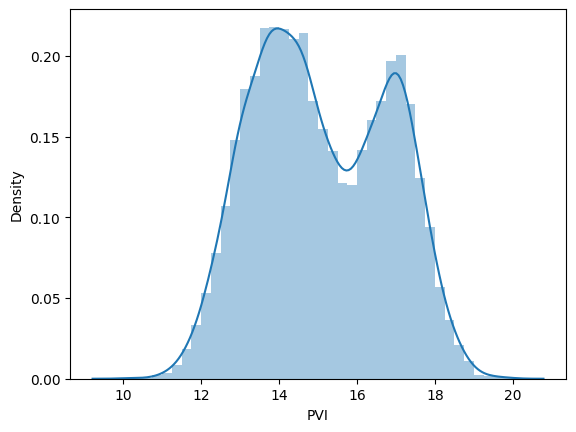

In [253]:
sns.distplot(observations["PVI"])

In [254]:
kurtosis = scipy.stats.kurtosis(observations["PVI"], fisher = True)
print(kurtosis)

-0.988262139639676


## Hb Level

In [255]:
oor_amnt = sum((observations["Hb level"] > 18) | (observations["Hb level"] < 12))

print(observations["Hb level"].mean())
print(observations["Hb level"].median())
print(observations["Hb level"].var())
print(f"{oor_amnt} - values out of anticipated range")

15.148739929999401
15.199847161981658
0.6260796701654986
0 - values out of anticipated range


In [256]:
detected_outliers = detect_outliers(observations, "Hb level")
outliers_perc = (detected_outliers.sum()/observations["Hb level"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["Hb level"].mean())
print(observations[~detected_outliers]["Hb level"].median())
print(observations[~detected_outliers]["Hb level"].var())


0.82%
15.157725577819221
15.203397154812896
0.5838308034001022


In [257]:
replace_outliers(observations, detected_outliers, "Hb level", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


In [258]:
result = scipy.stats.anderson(observations["Hb level"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")


statistic, p_value = scipy.stats.kstest(observations["Hb level"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2143970335.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["Hb level"])


<Axes: xlabel='Hb level', ylabel='Density'>

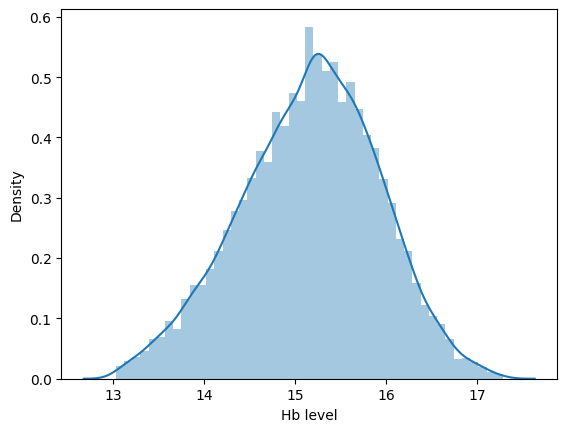

In [259]:
sns.distplot(observations["Hb level"])

In [260]:
kurtosis = scipy.stats.kurtosis(observations["Hb level"], fisher = True)
print(kurtosis)
print(scipy.stats.skew(observations["Hb level"]))

-0.2579519488671873
-0.18458727053932839


## Skin Temperature

In [261]:
oor_amnt = sum((observations["Skin Temperature"] > 38) | (observations["Skin Temperature"] < 33))

print(observations["Skin Temperature"].mean())
print(observations["Skin Temperature"].median())
print(observations["Skin Temperature"].var())
print(f"{oor_amnt} - values out of anticipated range")

35.865358092548455
35.9767089639813
0.6378122016251532
0 - values out of anticipated range


In [262]:
detected_outliers = detect_outliers(observations, "Skin Temperature")
outliers_perc = (detected_outliers.sum()/observations["Skin Temperature"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["Skin Temperature"].mean())
print(observations[~detected_outliers]["Skin Temperature"].median())
print(observations[~detected_outliers]["Skin Temperature"].var())


0.04%
35.86640959946512
35.976868085277545
0.6353792004375504


In [263]:
replace_outliers(observations, detected_outliers, "Skin Temperature", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


In [264]:
result = scipy.stats.anderson(observations["Skin Temperature"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")


statistic, p_value = scipy.stats.kstest(observations["Skin Temperature"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2258504596.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["Skin Temperature"])


<Axes: xlabel='Skin Temperature', ylabel='Density'>

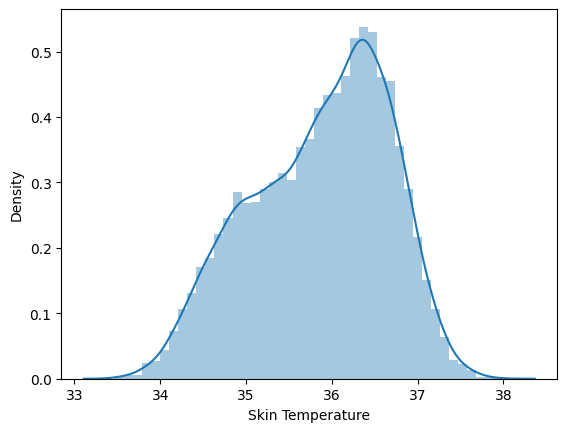

In [265]:
sns.distplot(observations["Skin Temperature"])

In [266]:
kurtosis = scipy.stats.kurtosis(observations["Skin Temperature"], fisher = True)
print(kurtosis)
scipy.stats.skew(observations["Skin Temperature"])

-0.6523754505014692


np.float64(-0.3487969106636011)

## SpO₂

In [267]:
oor_amnt = sum((observations["SpO₂"] > 100) | (observations["SpO₂"] < 95))

print(observations["SpO₂"].mean())
print(observations["SpO₂"].median())
print(observations["SpO₂"].var())
print(f"{oor_amnt} - values out of anticipated range")

97.33102684344969
97.34556879582168
0.48884729684797
0 - values out of anticipated range


In [268]:
detected_outliers = detect_outliers(observations, "SpO₂")
outliers_perc = (detected_outliers.sum()/observations["SpO₂"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["SpO₂"].mean())
print(observations[~detected_outliers]["SpO₂"].median())
print(observations[~detected_outliers]["SpO₂"].var())


0.11%
97.33119100604625
97.34571978695558
0.483906245580824


In [269]:
replace_outliers(observations, detected_outliers, "SpO₂", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


In [270]:
result = scipy.stats.anderson(observations["SpO₂"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")


statistic, p_value = scipy.stats.kstest(observations["SpO₂"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3106311098.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["SpO₂"])


<Axes: xlabel='SpO₂', ylabel='Density'>

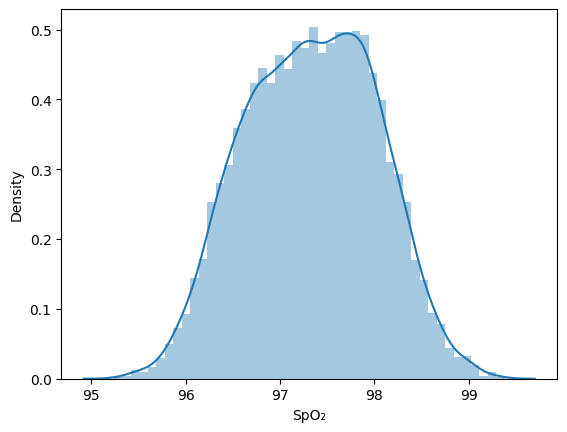

In [271]:
sns.distplot(observations["SpO₂"])

In [272]:
kurtosis = scipy.stats.kurtosis(observations["SpO₂"], fisher = True)
print(kurtosis)

-0.5760691237062976


## HR

In [273]:
oor_amnt = sum((observations["HR"] > 100) | (observations["HR"] < 60))

print(observations["HR"].mean())
print(observations["HR"].median())
print(observations["HR"].var())
print(f"{oor_amnt} - values out of anticipated range")

78.1432263210654
78.12316675714767
22.92228725256945
0 - values out of anticipated range


In [274]:
detected_outliers = detect_outliers(observations, "HR")
outliers_perc = (detected_outliers.sum()/observations["HR"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["HR"].mean())
print(observations[~detected_outliers]["HR"].median())
print(observations[~detected_outliers]["HR"].var())


0.67%
78.13783421965735
78.1199979753683
21.663309334177743


In [275]:
replace_outliers(observations, detected_outliers, "HR", method = "capping", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(cond_less, other = dataframe[column_name].quantile(0.05), inplace = True)
C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

In [276]:
result = scipy.stats.anderson(observations["HR"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["HR"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")


[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2712236027.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["HR"])


<Axes: xlabel='HR', ylabel='Density'>

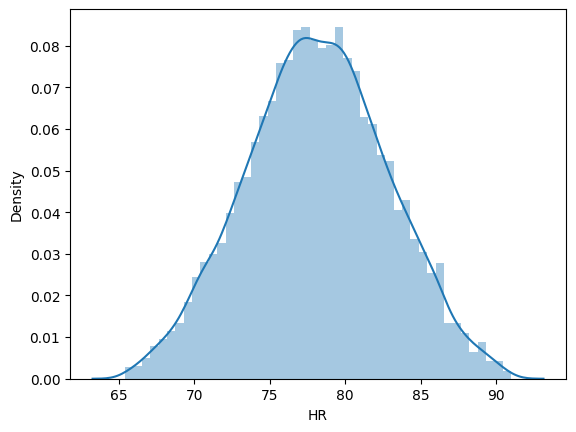

In [277]:
sns.distplot(observations["HR"])

In [278]:
kurtosis = scipy.stats.kurtosis(observations["HR"], fisher = True)
skewness = scipy.stats.skew(observations["HR"])

print(kurtosis)
print(skewness)

-0.3353160795052883
-0.0005174763020104078


## RR

In [279]:
oor_amnt = sum((observations["RR"] > 20) | (observations["RR"] < 12))

print(observations["RR"].mean())
print(observations["RR"].median())
print(observations["RR"].var())
print(f"{oor_amnt} - values out of anticipated range")

16.54583400300499
16.61632880354653
1.6618234335050115
0 - values out of anticipated range


In [280]:
detected_outliers = detect_outliers(observations, "RR")
outliers_perc = (detected_outliers.sum()/observations["RR"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["RR"].mean())
print(observations[~detected_outliers]["RR"].median())
print(observations[~detected_outliers]["RR"].var())


0.07%
16.54856692372161
16.61722199738725
1.6515662953790493


In [281]:
replace_outliers(observations, detected_outliers, "RR", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


In [282]:
result = scipy.stats.anderson(observations["RR"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["RR"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


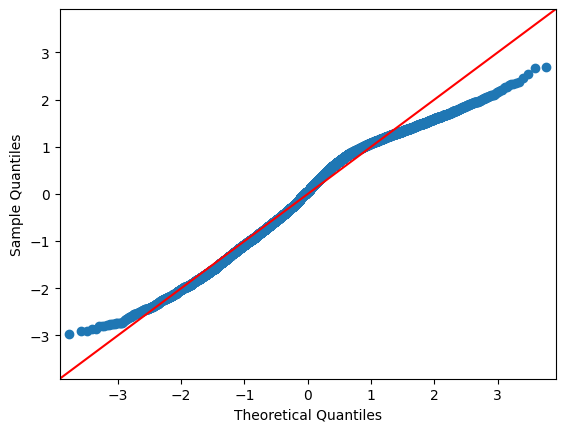

In [283]:
dgraph_ = sm.ProbPlot(observations["RR"], fit = True).qqplot(line = "45")

In [284]:
kurtosis = scipy.stats.kurtosis(observations["RR"], fisher = True)
skewness = scipy.stats.skew(observations["RR"])

print(kurtosis)
print(skewness)

-0.7268697889133717
-0.2940065922902226


## FiO₂

In [285]:
oor_amnt = sum((observations["FiO₂"] > 100) | (observations["FiO₂"] < 21))

print(observations["FiO₂"].mean())
print(observations["FiO₂"].median())
print(observations["FiO₂"].var())
print(f"{oor_amnt} - values out of anticipated range")

58.05792312128634
57.88400115557979
86.21221392461845
0 - values out of anticipated range


In [286]:
detected_outliers = detect_outliers(observations, "FiO₂")
outliers_perc = (detected_outliers.sum()/observations["FiO₂"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["FiO₂"].mean())
print(observations[~detected_outliers]["FiO₂"].median())
print(observations[~detected_outliers]["FiO₂"].var())


1.51%
58.001410507717274
57.86288469315155
75.56343971464172


In [287]:
replace_outliers(observations, detected_outliers, "FiO₂", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


In [288]:
result = scipy.stats.anderson(observations["FiO₂"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["FiO₂"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")


[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3696350386.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["FiO₂"])


<Axes: xlabel='FiO₂', ylabel='Density'>

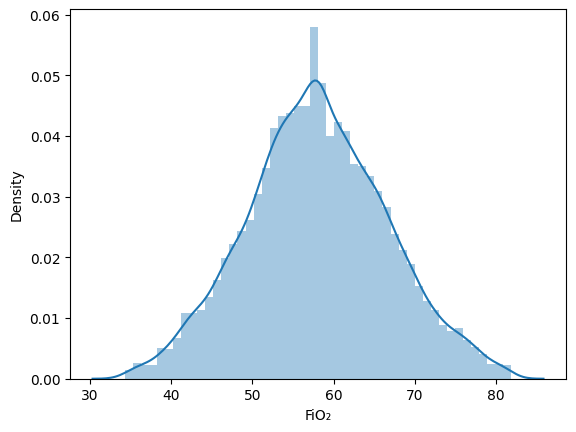

In [289]:
sns.distplot(observations["FiO₂"])


In [290]:
kurtosis = scipy.stats.kurtosis(observations["FiO₂"], fisher = True)
skewness = scipy.stats.skew(observations["FiO₂"])
print(kurtosis)
print(skewness)

-0.18443393566280264
0.05812663205254598


## Blood Flow Index

In [291]:
print(observations["Blood Flow Index"].mean())
print(observations["Blood Flow Index"].median())
print(observations["Blood Flow Index"].var())

52.71626266716956
52.66583652179975
186.28648239622416


In [292]:
detected_outliers = detect_outliers(observations, "Blood Flow Index")
outliers_perc = (detected_outliers.sum()/observations["Blood Flow Index"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["Blood Flow Index"].mean())
print(observations[~detected_outliers]["Blood Flow Index"].median())
print(observations[~detected_outliers]["Blood Flow Index"].var())


0.66%
52.70529968033122
52.660090276145866
176.25058763086864


In [293]:
remove_outliers(observations, detected_outliers, inplace = True)


In [294]:
result = scipy.stats.anderson(observations["Blood Flow Index"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["Blood Flow Index"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1358749246.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["Blood Flow Index"])


<Axes: xlabel='Blood Flow Index', ylabel='Density'>

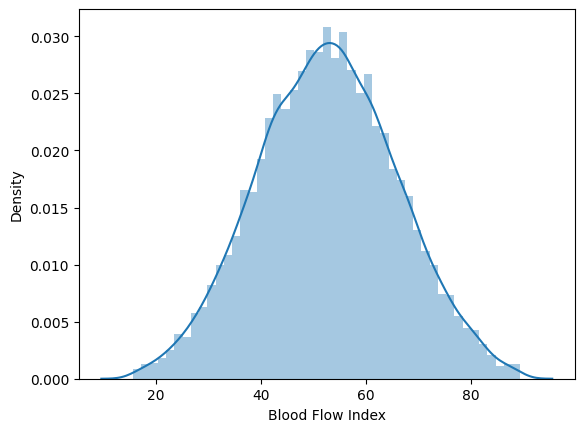

In [295]:
sns.distplot(observations["Blood Flow Index"])

In [296]:
kurtosis = scipy.stats.kurtosis(observations["Blood Flow Index"], fisher = True)
print(kurtosis)

-0.2892058201211576


## Respiratory Effort

In [297]:
print(observations["Respiratory effort"].mean())
print(observations["Respiratory effort"].median())
print(observations["Respiratory effort"].var())

48.89161654901714
48.90865127735999
138.9896362246266


In [298]:
detected_outliers = detect_outliers(observations, "Respiratory effort")
outliers_perc = (detected_outliers.sum()/observations["Respiratory effort"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["Respiratory effort"].mean())
print(observations[~detected_outliers]["Respiratory effort"].median())
print(observations[~detected_outliers]["Respiratory effort"].var())


0.86%
48.822551305484204
48.89004665514421
129.22438667343482


In [299]:
remove_outliers(observations, detected_outliers, inplace = True)

In [300]:
result = scipy.stats.anderson(observations["Respiratory effort"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["Respiratory effort"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


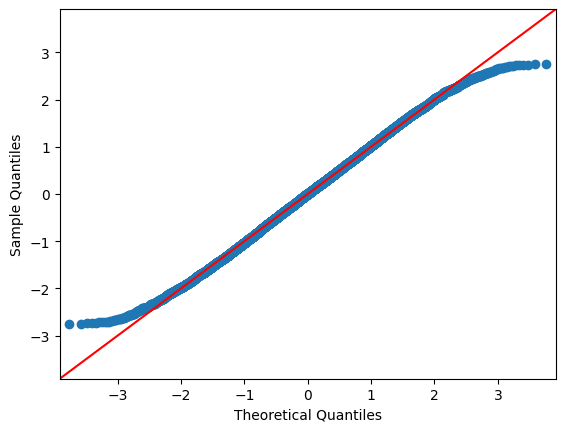

In [301]:
dgraph_ = sm.ProbPlot(observations["Respiratory effort"], fit = True).qqplot(line = "45")

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1358749246.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["Blood Flow Index"])


<Axes: xlabel='Blood Flow Index', ylabel='Density'>

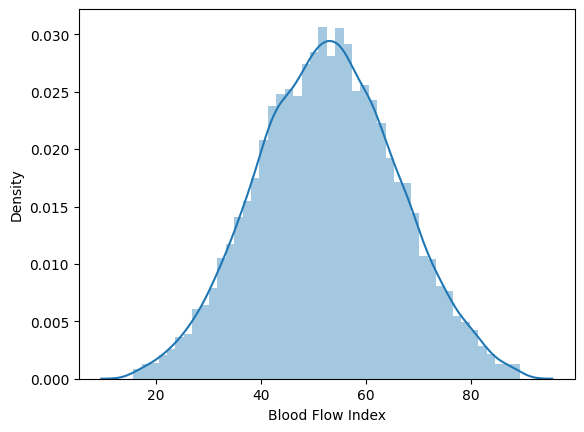

In [302]:
sns.distplot(observations["Blood Flow Index"])

In [303]:
kurtosis = scipy.stats.kurtosis(observations["Blood Flow Index"], fisher = True)
skewness = scipy.stats.skew(observations["Blood Flow Index"])
print(kurtosis)
print(skewness)

-0.2880731274567423
0.01712111017292583


## O₂ extraction ratio

In [304]:
oor_amnt = sum((observations["O₂ extraction ratio"] > 0.3) | (observations["O₂ extraction ratio"] < 0.2))

print(observations["O₂ extraction ratio"].mean())
print(observations["O₂ extraction ratio"].median())
print(observations["O₂ extraction ratio"].var())

print(f"{oor_amnt} - values out of anticipated range")

0.24954630570585964
0.2491866262377956
0.0008348263003777884
0 - values out of anticipated range


In [305]:
detected_outliers = detect_outliers(observations, "O₂ extraction ratio")
outliers_perc = (detected_outliers.sum()/observations["O₂ extraction ratio"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["O₂ extraction ratio"].mean())
print(observations[~detected_outliers]["O₂ extraction ratio"].median())
print(observations[~detected_outliers]["O₂ extraction ratio"].var())


0.00%
0.24954630570585964
0.2491866262377956
0.0008348263003777884


In [306]:
result = scipy.stats.anderson(observations["O₂ extraction ratio"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["O₂ extraction ratio"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\4222409318.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["O₂ extraction ratio"])


<Axes: xlabel='O₂ extraction ratio', ylabel='Density'>

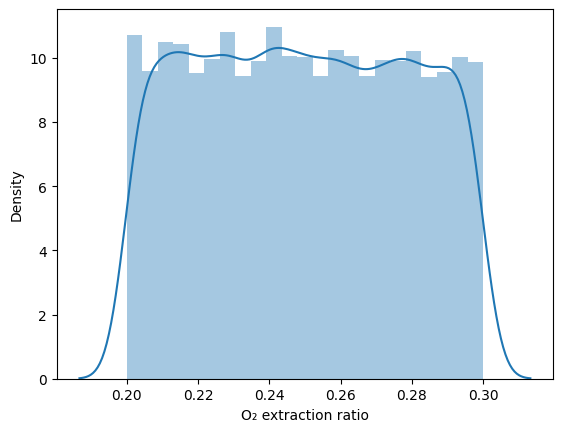

In [307]:
sns.distplot(observations["O₂ extraction ratio"])

In [308]:
scipy.stats.kurtosis(observations["O₂ extraction ratio"])

np.float64(-1.1958711440429155)

## BP

In [309]:
oor_amnt = sum((observations["BP"] > 120) | (observations["BP"] < 90))

print(observations["BP"].mean())
print(observations["BP"].median())
print(observations["BP"].var())
print(f"{oor_amnt} - values out of anticipated range")

104.44361064985848
104.40050579235584
16.69703588305045
0 - values out of anticipated range


In [310]:
detected_outliers = detect_outliers(observations, "BP")
outliers_perc = (detected_outliers.sum()/observations["BP"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["BP"].mean())
print(observations[~detected_outliers]["BP"].median())
print(observations[~detected_outliers]["BP"].var())


0.53%
104.4510810849371
104.40561125942969
15.998638578718353


In [311]:
replace_outliers(observations, detected_outliers, "BP", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


In [312]:
result = scipy.stats.anderson(observations["BP"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["BP"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[ True] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\519451906.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["BP"])


<Axes: xlabel='BP', ylabel='Density'>

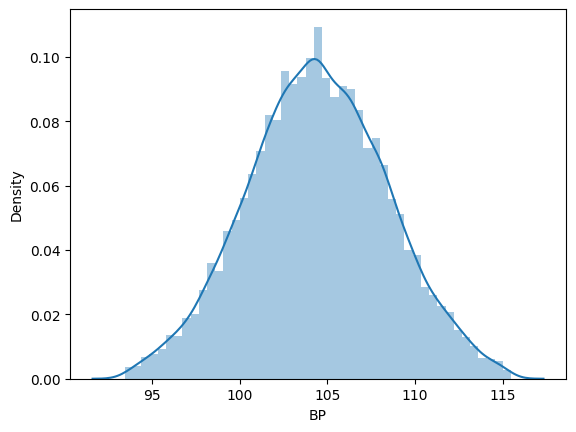

In [313]:
sns.distplot(observations["BP"])

In [314]:
kurtosis = scipy.stats.kurtosis(observations["Blood Flow Index"], fisher = True)
print(kurtosis)

-0.2880731274567423


## Longitude

In [315]:
oor_amnt = sum((observations["longitude"] > 180.00) | (observations["longitude"] < -180.00))

print(observations["longitude"].mean())
print(observations["longitude"].median())
print(observations["longitude"].var())
print(f"{oor_amnt} - values out of anticipated range")

8.724024789557358
9.02596
5493.807532974897
0 - values out of anticipated range


In [316]:
result = scipy.stats.anderson(observations["longitude"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["longitude"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1479643801.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["longitude"])


<Axes: xlabel='longitude', ylabel='Density'>

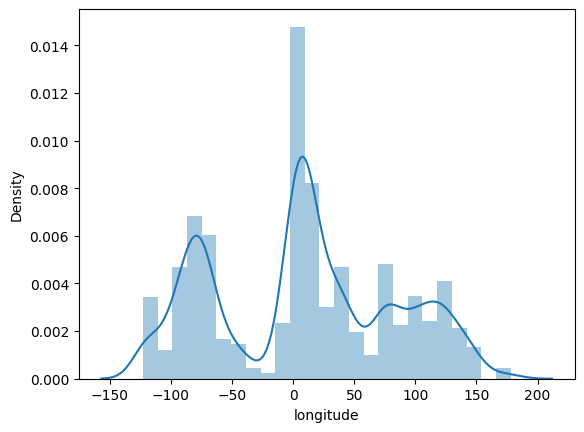

In [317]:
sns.distplot(observations["longitude"])

## Latitude

In [318]:
oor_amnt = sum((observations["latitude"] > 90.00) | (observations["latitude"] < -90.00))

print(observations["latitude"].mean())
print(observations["latitude"].median())
print(observations["latitude"].var())
print(f"{oor_amnt} - values out of anticipated range")

29.995151952221573
37.19723
506.6831928425033
0 - values out of anticipated range


In [319]:
result = scipy.stats.anderson(observations["latitude"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["latitude"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


<Axes: ylabel='latitude'>

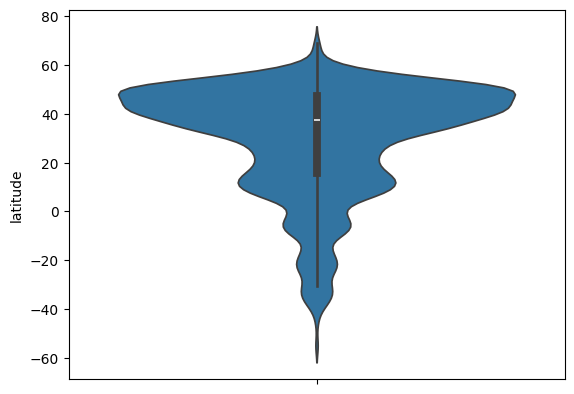

In [320]:
# dgraph_ = sm.ProbPlot(observations["latitude"], fit = True).qqplot(line = "45")
sns.violinplot(observations["latitude"])

## Correlation testing

<h4>Point-Biseliar correlation was chosen since it's used between a continuous variable and a binary variable</h4>


In [321]:
possible_attributes = [] #significant attributes
ocorr_att = [] #attributes corelating with oximetry well enough 
for k in list(observations.columns):
    if (k != "oximetry"):
        r, p = scipy.stats.pointbiserialr(observations["oximetry"], observations[k])
        if (p < 0.05/b_value):
            possible_attributes.append(k)
        if (abs(r) >= 0.25):
            ocorr_att.append(k)
        print(f"{k}: {r*100:.2f}%")
                        
print(possible_attributes)


SpO₂: 26.20%
HR: 0.79%
PI: 0.09%
RR: 64.98%
EtCO₂: 0.32%
FiO₂: 1.20%
PRV: -1.48%
BP: 0.49%
Skin Temperature: 36.92%
Motion/Activity index: -0.73%
PVI: -9.12%
Hb level: -8.66%
SV: 0.01%
CO: -0.12%
Blood Flow Index: 0.60%
PPG waveform features: 0.33%
Signal Quality Index: 1.51%
Respiratory effort: -0.87%
O₂ extraction ratio: -0.22%
SNR: -1.27%
latitude: 2.36%
longitude: 0.18%
['SpO₂', 'RR', 'Skin Temperature', 'PVI', 'Hb level']


In [322]:
pcorr_attributes = [] #partially correlated attributes that might correlate well with oximetry without impact of other, significant attributes

td_attr = list(observations.columns.drop(possible_attributes + ["oximetry"]))

for cov_var in td_attr:
    result = pg.partial_corr(data = observations, x = 'oximetry', y = cov_var, covar = possible_attributes, method='spearman')
    p = result["p-val"].values[0]
    if(p < (0.05/b_value)): #check whether the result is statistically significant with help of p-value and whether correlation is strong enough
        pcorr_attributes.append(cov_var)
        corr_coeff = result["r"].values[0]
        r_value = result["r"].values[0]
        print("%.3f for 'oximetry' and '%s'" % (corr_coeff, cov_var))
        if((abs(r_value)) >= 0.4):
            ocorr_att.append(f"{cov_var}: {r_value}")

print(set(pcorr_attributes))


set()


<h4>Thus none of the significantly correlated attributes towards oximetry interfere in correlation between oximetry and other attributes. </h4>


In [323]:
#Finally putting everything together
possible_attributes.extend(pcorr_attributes) #append partially correlated attributes

possible_attributes = list(set(possible_attributes)) #remove duplicates
ocorr_att = list(set(ocorr_att)) #remove duplicates

print(f"{possible_attributes} - attributes that might be significant")
print(f"{ocorr_att} - attributes that correlate substantially with oximetry dependent variable")


['SpO₂', 'Hb level', 'PVI', 'RR', 'Skin Temperature'] - attributes that might be significant
['SpO₂', 'RR', 'Skin Temperature'] - attributes that correlate substantially with oximetry dependent variable


In [324]:
pa_dict = {value: set() for value in possible_attributes} #attributes that correlate well with oximetry, for each of them found attributes that correlate well with them
for attr in possible_attributes:
    for col in list(observations.columns.drop("oximetry")):
        if (col not in possible_attributes):
            r, p = scipy.stats.spearmanr(observations[attr], observations[col])
            if(p < 0.05/b_value):
                pa_dict[attr].add(col)
print(pa_dict)


{'SpO₂': {'FiO₂'}, 'Hb level': set(), 'PVI': {'FiO₂'}, 'RR': {'FiO₂'}, 'Skin Temperature': {'FiO₂'}}



<h4>So there are no additional attributes correlate sufficiently statistically with oximetry correlated attributes</h4>

<h4>
The reason spearman correlation was chosen to test correlation between variables is the fact that some of them aren't from normal distribution. That fact is proven by previous visualization of features and normality tests
</h4>

SpO₂:
(oximetry > 0.27) (RR > 0.30) (PVI > 0.36) (Hb level > 0.20) 

HR:
(CO > 1.00) 

RR:
(FiO₂ > 0.12) (oximetry > 0.65) (Skin Temperature > 0.33) 

Skin Temperature:
(oximetry > 0.41) 

SpO₂:
(FiO₂ > -0.14) 

Skin Temperature:
(PVI > -0.44) 



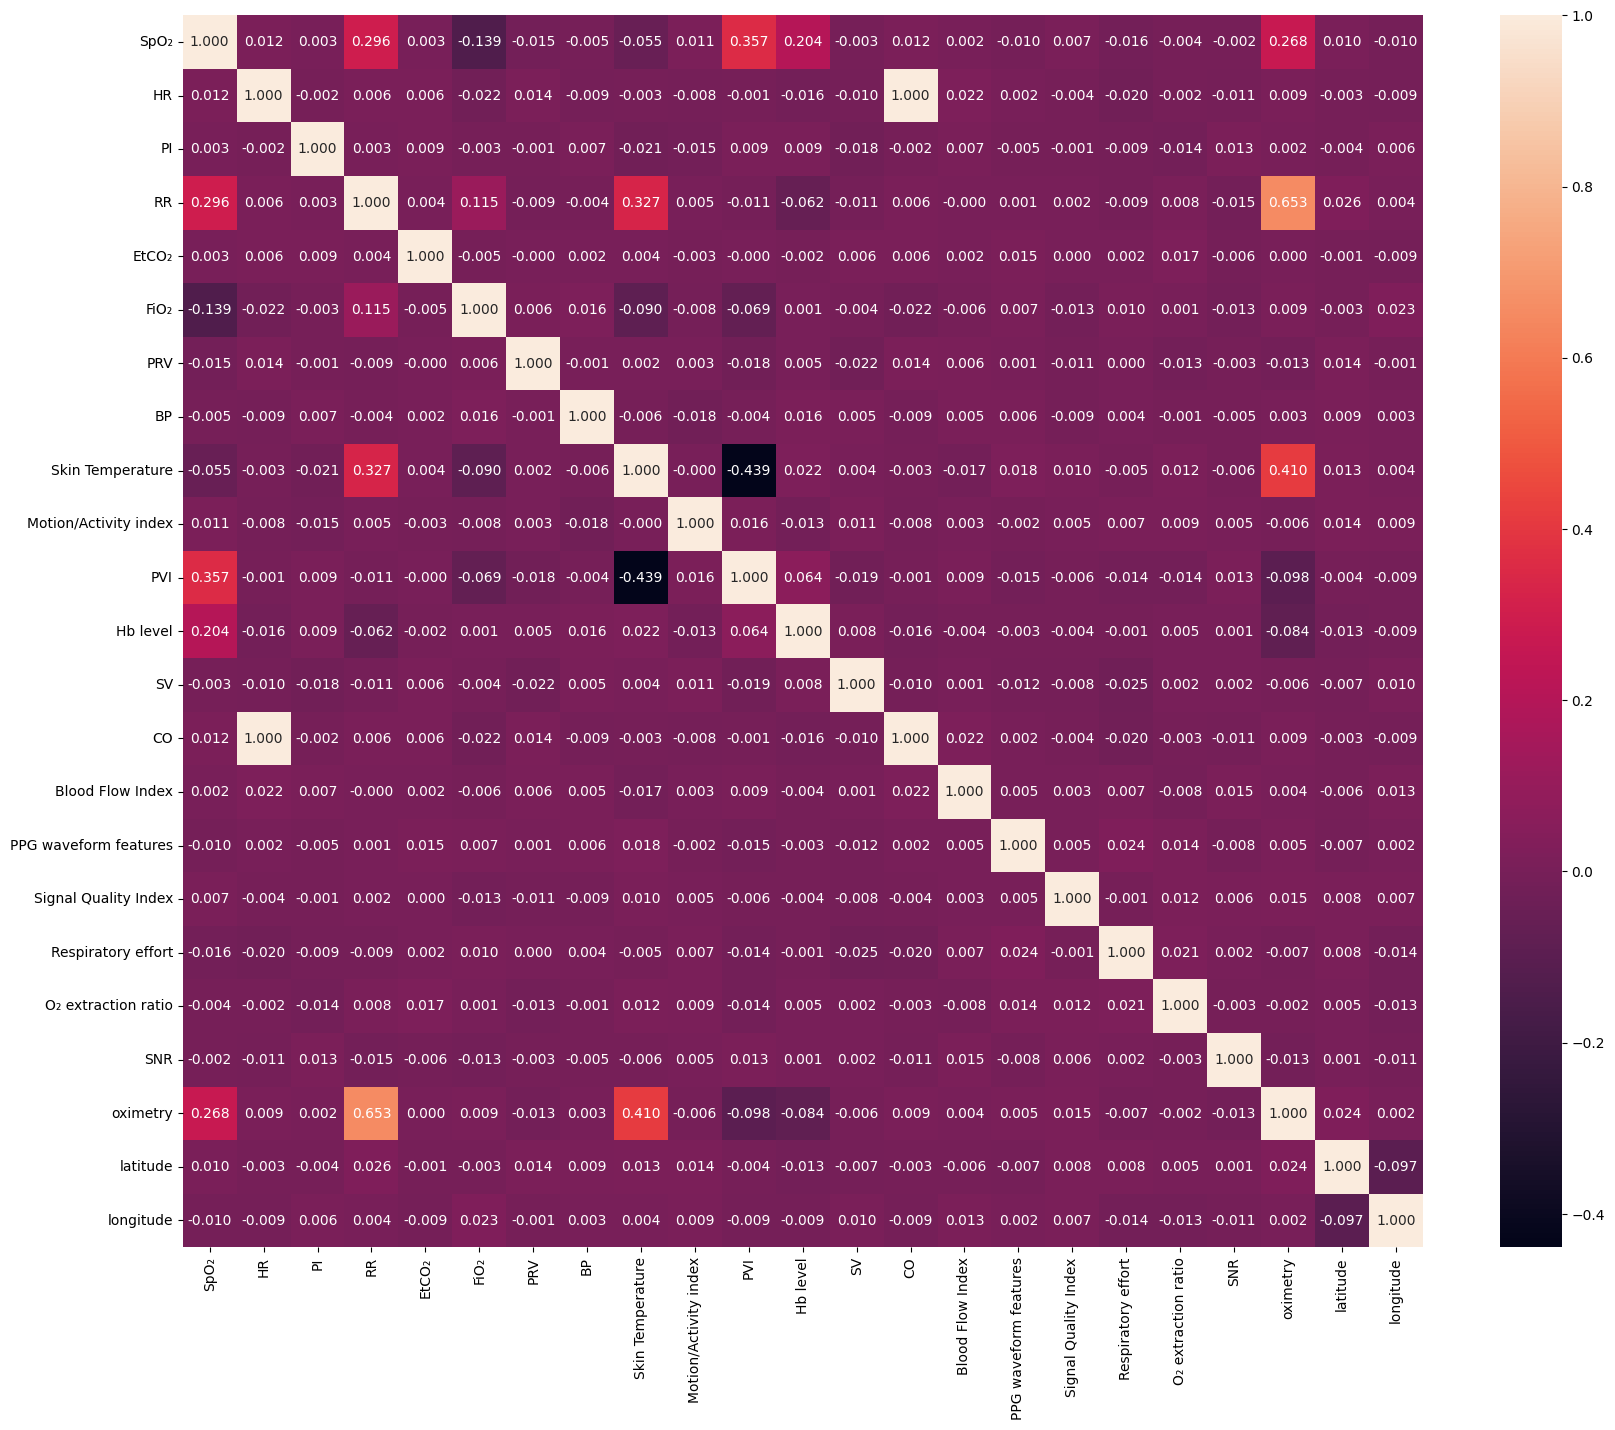

In [325]:
correlation_matrix = observations.corr(method = "spearman", numeric_only = True)
fig, ax = plt.subplots(figsize=(20,16))
sns.heatmap(correlation_matrix, ax=ax, annot=True, fmt = '.3f')

pos_corr = {} #attributes that correlate positively with each other
neg_corr = {} #attributes that correlate negatively with each other

u_dict = None

for i in range(0, 22):
    for k in range(i + 1, 23):
        corr_coeff = correlation_matrix.iat[i, k]
        if(abs(corr_coeff) >= 0.1):
            cell = np.where(correlation_matrix == correlation_matrix.iat[i, k])
            row_name = list(observations.columns)[cell[0][0]]
            col_name = list(observations.columns)[cell[1][0]]
            if(corr_coeff > 0):
                u_dict = pos_corr
            else:
                u_dict = neg_corr
            if(u_dict.get(row_name) == None):
                u_dict[row_name] = {"%s > %.2f" % (col_name, corr_coeff)} 
            else:
                u_dict[row_name].add("%s > %.2f" % (col_name, corr_coeff))

for k in pos_corr.keys():
    cv = list(pos_corr[k])
    print(f"{k}:")
    for p in range(len(cv)):
        print(f"({cv[p]})", end = " ")
    print("\n")

for k in neg_corr.keys():
    cv = list(neg_corr[k])
    print(f"{k}:")
    for p in range(len(cv)):
        print(f"({cv[p]})", end = " ")
    print("\n")



<h4>
Eventually we aren't able to merge other datasets with <b>observations</b> dataset due to lack of data in them as well as lack of information about them.
</h4>

# Data Cleaning and Integration

## Data Cleaning

In [326]:
dup_observ = observations.duplicated(keep = "first")
print(dup_observ.any().sum())
observations.drop_duplicates(inplace = True)


1


In [327]:
print(observations.shape)
observations.head(3)


(11950, 23)


,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,96.615321,66.240820,10.877068,15.668587,39.658243,68.389223,96.163913,100.816532,35.751151,12.129743,...,4.002266,47.010676,54.479165,41.743618,50.708816,0.259091,39.107576,0.0,53.60520,10.03988
1,97.857755,71.825379,8.921403,16.552066,40.874901,44.950264,120.131860,104.400506,36.615192,10.568549,...,4.010066,57.466919,42.151782,40.852335,36.853826,0.240683,25.113412,1.0,43.78956,7.60872
2,96.631890,85.995153,12.541174,15.618439,41.920327,56.997064,169.416508,106.999465,36.103454,10.990277,...,4.758854,50.900908,67.493365,25.994388,54.595833,0.296654,39.118661,0.0,-30.60106,-71.19901


In [328]:
o2er_limit = observations["O₂ extraction ratio"].quantile(0.985)
st_limit_h = observations["Skin Temperature"].quantile(0.985) 
st_limit_l = observations["Skin Temperature"].quantile(0.965) 
re_limit = observations["Respiratory effort"].quantile(0.965)
spo2_limit = observations["SpO₂"].quantile(0.965)
pvi_limit = observations["PVI"].quantile(0.965)
sv_limit_l = observations["SV"].quantile(0.965) 
sv_limit_h = observations["SV"].quantile(0.965)
prv_limit = observations["PRV"].quantile(0.965)
rr_limit = observations["RR"].quantile(0.965)


bfi_limit = observations["Blood Flow Index"].quantile(0.035) 
fio2_limit = observations["FiO₂"].quantile(0.035)
hr_limit = observations["HR"].quantile(0.035) 
co_limit_h = observations["CO"].quantile(0.035) 
co_limit_l = observations["CO"].quantile(0.015)
hr_limit_l = observations["HR"].quantile(0.015) 

#high prv and low bfi
#high skin temperature and low HR or low Blood Flow Index
#High RR and low HR
#High PVI and low SV
#high SNR and low Signal Quality Index
#High O2 extraction and low CO


mask_1 = (observations["SpO₂"] > spo2_limit) & (observations["FiO₂"] < fio2_limit)
mask_2 = (observations["SV"] > sv_limit_h) & (observations["CO"] < co_limit_h)   
mask_3 = (observations["Respiratory effort"] > re_limit) & (observations["Blood Flow Index"] < bfi_limit)
mask_4 = (observations["PRV"] > prv_limit) & (observations["Blood Flow Index"] < bfi_limit)
mask_5 = (observations["Skin Temperature"] > st_limit_h) & (observations["HR"] < hr_limit_l)
mask_6 = (observations["Skin Temperature"] > st_limit_l) & (observations["Blood Flow Index"] < bfi_limit)
mask_7 = (observations["RR"] > rr_limit) & (observations["HR"] < hr_limit)
mask_8 = (observations["PVI"] > pvi_limit) & (observations["SV"] > sv_limit_l)
mask_9 = (observations["O₂ extraction ratio"] > o2er_limit) & (observations["CO"] < co_limit_l)


In [329]:
print(len(list(observations[mask_1].index))) #Abnormally high SpO2 despite FiO2 being concurrently low. It's very unlikely to have highly saturated blood with oxygen while having low fraction of inspired oxygen.
print(len(list(observations[mask_2].index))) #High SV but low CO is abnormal. CO depends partially on SV, the higher SV is the higher CO is.
print(len(list(observations[mask_3].index))) #Inconsistency between Respiratory effort and Bloodflow Index. Concurrently as Respiratory Effort increeases Blood Flow Index must increase also
print(len(list(observations[mask_4].index))) #Inconsistency between Respiratory effort and PRV
print(len(list(observations[mask_5].index))) #Abnormally high Skin Temperature although HR is low, if Skin Temperature increases, HR must also increase 
print(len(list(observations[mask_6].index))) #Abnormaly high Skin Temperature although Blood Flow Index is low. When Skin Temperature increases Blood Flow Index must increase as well
print(len(list(observations[mask_7].index))) #Inconsistency between HR and RR, HR must increase if RR increases
print(len(list(observations[mask_8].index))) #Inconsistency between PVI and SV. Heart must pump blood harder(High PVI) with bigger SV when body doesn't have enough blood
print(len(list(observations[mask_9].index))) #Inconsistency between high O₂ extraction ratio and low CO


47
15
23
14
4
23
17
10
2


In [330]:
remove_outliers(observations, mask_1, inplace = True)
remove_outliers(observations, mask_2, inplace = True)
remove_outliers(observations, mask_3, inplace = True)
remove_outliers(observations, mask_4, inplace = True)
remove_outliers(observations, mask_5, inplace = True)
remove_outliers(observations, mask_6, inplace = True)
remove_outliers(observations, mask_7, inplace = True)
remove_outliers(observations, mask_8, inplace = True)
remove_outliers(observations, mask_9, inplace = True)

In [331]:
observations.shape

(11799, 23)

## Hypothesis Testing

### Hypothesis No. 1

In [332]:
analysis = statsmodels.stats.power.TTestIndPower()
analysis_p = statsmodels.stats.power.NormalIndPower()

In [333]:
ocorr_att

['SpO₂', 'RR', 'Skin Temperature']

In [334]:
print(observations[observations["RR"] > observations["RR"].mean()]["oximetry"].value_counts())
print(observations[observations["RR"] < observations["RR"].mean()]["oximetry"].value_counts())

oximetry
1.0    5426
0.0     671
Name: count, dtype: int64
oximetry
0.0    4099
1.0    1603
Name: count, dtype: int64


<h3>
Hypothesis question:
<br>-Are observations with "RR-value" higher than "RR-mean" have higher probability of having oximetry equating to 1 than to 0?
</h3>
<h4>
H0: Observations with "RR-value" higher than "RR-mean" have the same "oximeter-mean" value as those with "RR-value" lower than "RR-mean"<br>
H1: Observations with "RR-value" higher than "RR-mean" have bigger "oximeter-mean" value than those with "RR-value" lower than "RR-mean"
</h4>

In [335]:
top_rr = observations[observations["RR"] > observations["RR"].mean()]
counts_tr = top_rr["oximetry"].sum()
nobs_tr = len(top_rr)

bott_rr = observations[observations["RR"] < observations["RR"].mean()]
counts_br = bott_rr["oximetry"].sum()
nobs_br = len(bott_rr)

counts = [counts_tr, counts_br]
nobs = [nobs_tr, nobs_br]

<pre>
<h4>
Since we need to compare proportions 2 data samples, Proportions Z-Test can be used to compare them.

Prerequisites for the test:
    -Binary/Dichotomous outcome variable: oximetry in our case
    -Independent samples: since both "high RR" and "low RR" are divided by mean, and from one sample they are independent
    -Sample size must satisfy the size requirements: n * p > 10 and n * (1 - p) > 10, where n is the sample size
     and p is the proportion population. p = number of all successes(1s)/number of all occurrences.
     The condition must work for both samples
     
So 1st and 2nd conditions were met. Let's test 3rd.
</h4>
</pre>

In [336]:
p = len(observations[observations["oximetry"] == 1])/len(observations["oximetry"])
print(p)

print(((nobs_tr * p) > 10) and ((nobs_tr * (1 - p)) > 10) and ((nobs_br * p) > 10) and ((nobs_br * (1 - p)) > 10))

0.5957284515636918
True


<h4>So all the criteria are fulfilled and therefore we can run the test</h4>

In [337]:
z_stat, p_value = statsmodels.stats.proportion.proportions_ztest(count = counts, nobs = nobs, alternative = "larger")


In [338]:
print(f"{p_value > 0.05/b_value} - fail to reject H0/reject H0")

False - fail to reject H0/reject H0


<h4>Well, that means that the difference is statistically significant and those people that have higher RR have higher probability of having oximetry equated to 1</h4>

In [339]:
phi = np.sqrt(z_stat**2/(nobs_tr + nobs_br))
phi

np.float64(0.6199435114803474)

In [340]:
required_size = analysis_p.solve_power(effect_size = phi, alpha = 0.05/b_value, power = 0.8)
sh_power = analysis_p.solve_power(effect_size = phi, alpha = 0.05/b_value, nobs1 = nobs_tr)
sl_power = analysis_p.solve_power(effect_size = phi, alpha = 0.05/b_value, nobs1 = nobs_br)

print(f"{required_size} - required size")
print(f"{sh_power} - power of dataset that has higher value than average")
print(f"{sl_power} - power of dataset that has lower value than average")

120.55219004102922 - required size
1.0 - power of dataset that has higher value than average
1.0 - power of dataset that has lower value than average


### Hypothesis No. 2

In [341]:
print(observations[observations["oximetry"] == 1]["Skin Temperature"].mean())
print(observations[observations["oximetry"] == 0]["Skin Temperature"].mean())

36.10351059148959
35.510353874197115


<h3>
Hypothesis question:
<br>-Are observations with "oximetry-value" of 1 have the same "Skin Temperature mean" value as observations with "oximetry-value" of 0
</h3>
<h4>
H0: Observations with "oximetry-value" of 1 have the same "Skin Temperature mean" value as observations with "oximetry-value" of 0<br>
H1: Observations with "oximetry-value" of 1 have higher "Skin Temperature mean" value then observations with "oximetry-value" of 0
</h4>

In [342]:
htm_st = observations[observations["oximetry"] == 1]["Skin Temperature"]
htm_stl = len(htm_st)

ltm_st = observations[observations["oximetry"] == 0]["Skin Temperature"]
ltm_stl = len(ltm_st)

print(htm_stl)
print(ltm_stl)


7029
4770


In [343]:
stc1, p_v1 = scipy.stats.kstest(htm_st, "norm")
stc2, p_v2 = scipy.stats.kstest(ltm_st, "norm")

print((p_v1 > 0.05/b_value) and (p_v2 > 0.05/b_value))

False


C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3102188493.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(htm_st)
C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3102188493.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ltm_st)


<Axes: xlabel='Skin Temperature', ylabel='Density'>

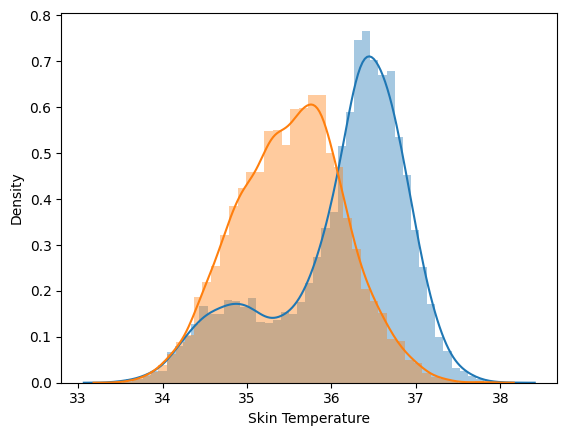

In [344]:
sns.distplot(htm_st)
sns.distplot(ltm_st)

<h4>They're both not normal and in both data samples we have more than 20 datapoints, thence Mann-Whitney U-Test can be used to determine whether their mean values are the same or mean value of first is higher than mean value of second</h4>

In [345]:
res = scipy.stats.mannwhitneyu(htm_st, ltm_st, alternative = "greater")
print(res.pvalue > 0.05/b_value)

False


<h4>
Due to result being false, we can reject H0 and accept the alternative H1. Thus Skin Temperature of people with oximetry of 1 is on average higher than Skin Temperature of people with oximetry of 0
</h4>

In [346]:
u_stat = res.statistic
mean_u = (htm_stl * ltm_stl) / 2
std_u = np.sqrt((htm_stl * ltm_stl * (htm_stl + ltm_stl + 1))/12)

stand_z = (u_stat - mean_u) / std_u
size_sqrt = np.sqrt(htm_stl + ltm_stl)

r_es = stand_z / size_sqrt
r_es

np.float64(0.40972240321564296)

In [347]:
required_size = analysis.solve_power(effect_size = r_es, alpha = 0.05/b_value, power = 0.8)
sh_power = analysis.solve_power(effect_size = r_es, alpha = 0.05/b_value, nobs1 = htm_stl)
sl_power = analysis.solve_power(effect_size = r_es, alpha = max(0.05/b_value, 1e-4), nobs1 = ltm_stl)


print(htm_stl)
print(ltm_stl)
print(r_es)

print(f"{required_size} - required size")
print(f"{sh_power} - power of dataset that has bigger value than average")
print(f"{sl_power} - power of dataset that has lower value than average")

7029
4770
0.40972240321564296
275.0000025 - required size
nan - power of dataset that has bigger value than average
nan - power of dataset that has lower value than average


<h4>
So for both hypotheses the power is significant enough for them to be truthful
</h4>

# Data Preprocessing

## Preprocessing

<h4>
Chosen attributes for further examination:<br>
PVI (10-20%) - Non-Gaussian Distribution<br>
Hb level (12-18 g/dL) - Non-Gaussian Distribution<br>
Skin Temperature (33–38 °C) - Non-Gaussian Distribution<br>
SpO₂ (95–100%) - Non-Gaussian Distribution<br> 
RR (12–20 breaths/min) - Non-Gaussian Distribution   <b>TAKEN_AS_SIGNIFICANT</b><br>
FiO₂ (21–100%) - Non-Gaussian Distribution<br>
Blood Flow Index (Relative units) - Non-Gaussian Distribution<br>
Respiratory effort (Relative units) - Non-Gaussian Distribution<br>
O₂ extraction ratio (0.2–0.3) - Non-Gaussian Distribution<br>
BP (90/60–120/80 mmHg) - Gaussian Distribution<br>
HR (60–100 bpm) - Non-Gaussian Distribution<br>
latitude (-90.00 to 90.00) - Non-Gaussian Distribution<br>
longitude (-180.00 to 180.00) - Non-Gaussian Distribution<br>
</h4>

<h4>The data is split using 70/30 - train/test data ratio</h4>

In [348]:
ctb_prepr = ["PVI", "Hb level", "Skin Temperature", "SpO₂", "RR", "FiO₂", "Blood Flow Index", "Respiratory effort", "O₂ extraction ratio", "BP", "HR", "latitude", "longitude", "oximetry"]
train_data = observations.iloc[int(len(observations)*0.3) + 1:, ][ctb_prepr]
test_data = observations.iloc[:int(len(observations)*0.3) + 1]
print(len(test_data))
print(len(train_data))

3540
8259


In [349]:
train_data.isna().sum().sum()

np.int64(0)

In [350]:
train_data.duplicated(keep = "first").sum()

np.int64(0)

<h1>Conclusion for Phase 1 – Converting Data into a Proper Format

</h1>

<h4>In the first stage of the project, the main objective was to bring the raw data into a unified, correct, and processable form suitable for subsequent analysis.</h4>
<h3> The following steps were carried out</h3>
<h4>
---All dates and timestamps were converted to a consistent format using the (unify_formats()) function, which resolved inconsistencies between different data sources.---

---Incorrect and missing values were removed or corrected, and outliers were detected and handled using the Interquartile Range (IQR) and 3 Standard Deviations (3SD) methods.---

---Categorical variables were standardized to a consistent type, numerical features were converted to appropriate numeric formats (float or int), and binary features were represented as logical (0/1).---

---The dataset structure was unified so that each row corresponds to a single observation and each column represents a specific feature.---


As a result of these transformations, the data were cleaned, harmonized, and prepared for the next stages — data preprocessing (Phase 2), including distribution transformations, normalization, standardization, and feature selection.
</h4>

<h4>Since all features except BP are Non-Gaussian, we would be required to do Normalization to them, and Standardization to BP feature. But before that we would be required to transform data. <br>Because oximetry is already transformed into binary format, and every other feature is continuous, we don't need any transformations regarding transofrmation of categorical variables. 2 transformations must be used and all the features except longitude and latitude have positive range of values, so Box-Cox and Yeo-Johnson transoformers will be used, correspondingly</h4>

In [351]:
pt_boxcox = sklearn.preprocessing.PowerTransformer(method = "box-cox", standardize = False)
pt_yejohn = sklearn.preprocessing.PowerTransformer(method = "yeo-johnson", standardize = False)

In [352]:
bc_cols = train_data.drop(["BP", "longitude", "latitude", "oximetry"], inplace = False, axis = 1)
yj_cols = train_data[["longitude", "latitude"]]
train_data[bc_cols.columns] = pt_boxcox.fit_transform(bc_cols)
train_data[yj_cols.columns] = pt_yejohn.fit_transform(yj_cols)

In [353]:
columns_tNormalize = list(train_data.columns)
columns_tNormalize.remove("BP")
columns_tNormalize.remove("oximetry")

norm_cols = train_data[columns_tNormalize]
stand_cols = train_data["BP"]

In [354]:
tmp_tdata = pd.DataFrame()
for column in columns_tNormalize:
    min_v = train_data[column].min()
    max_v = train_data[column].max()
    tmp_tdata[column] = (train_data[column] - min_v) / (max_v - min_v)
tmp_tdata["oximetry"] = train_data["oximetry"]
#here we normalize datapoints that belong to non-normal distributions

In [355]:
tmp_tdata["BP"] = (stand_cols - stand_cols.mean()) / stand_cols.std()
#here we standardize points that belong to normal distribution
tmp_tdata["BP"]

3642     0.367923
3643    -0.505095
3644     0.558724
3645     0.035746
3646    -2.017033
           ...   
12130   -0.769710
12131   -1.866072
12132    1.619992
12133   -0.662076
12134    0.587931
Name: BP, Length: 8259, dtype: float64

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3499903739.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["PVI"])


<Axes: xlabel='PVI', ylabel='Density'>

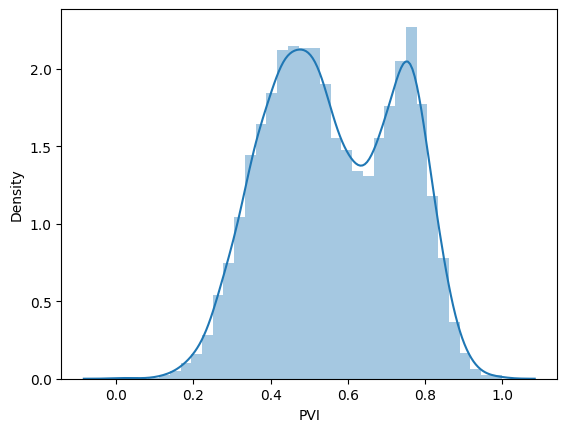

In [356]:
sns.distplot(tmp_tdata["PVI"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2476806813.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["Hb level"])


<Axes: xlabel='Hb level', ylabel='Density'>

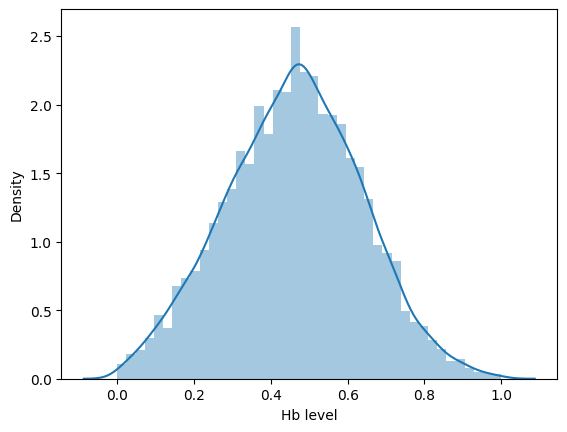

In [357]:
sns.distplot(tmp_tdata["Hb level"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\302499442.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["Skin Temperature"])


<Axes: xlabel='Skin Temperature', ylabel='Density'>

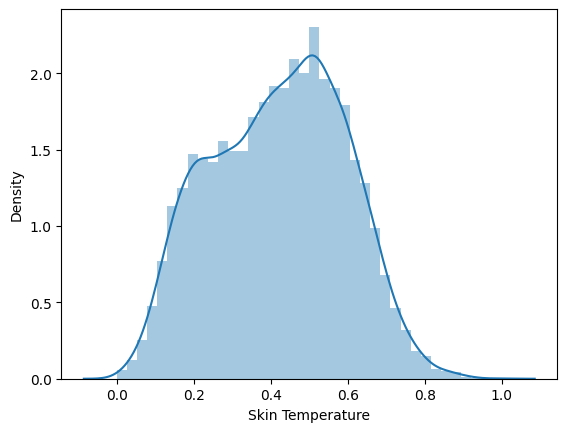

In [358]:
sns.distplot(tmp_tdata["Skin Temperature"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3833760495.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["SpO₂"])


<Axes: xlabel='SpO₂', ylabel='Density'>

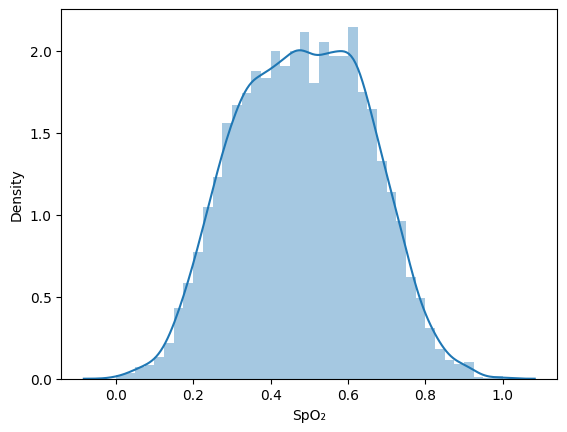

In [359]:
sns.distplot(tmp_tdata["SpO₂"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\402648581.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["RR"])


<Axes: xlabel='RR', ylabel='Density'>

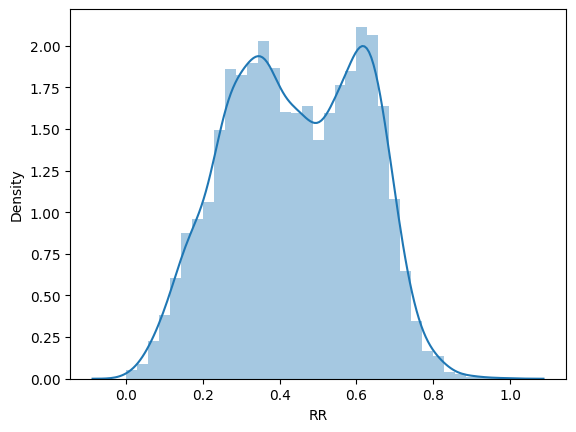

In [360]:
sns.distplot(tmp_tdata["RR"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1320184178.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["FiO₂"])


<Axes: xlabel='FiO₂', ylabel='Density'>

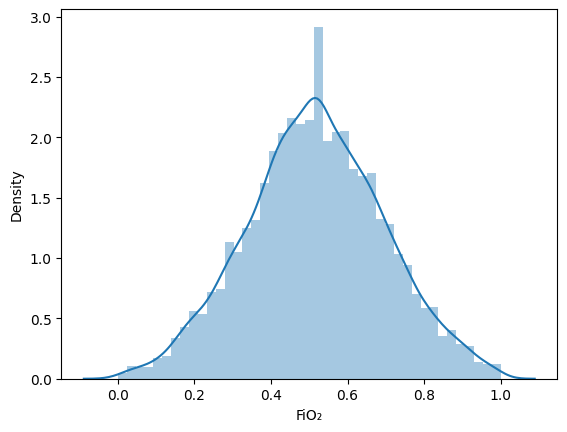

In [361]:
sns.distplot(tmp_tdata["FiO₂"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1750226016.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["Blood Flow Index"])


<Axes: xlabel='Blood Flow Index', ylabel='Density'>

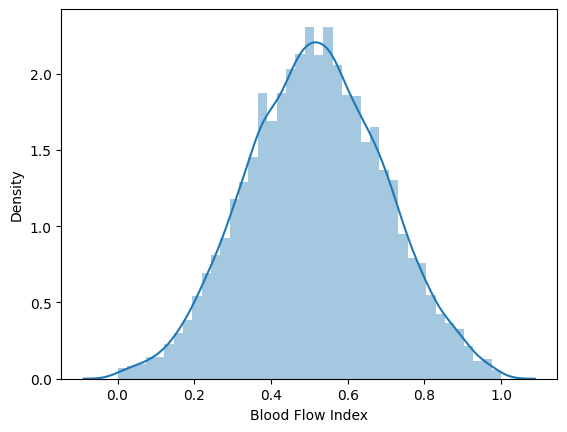

In [362]:
sns.distplot(tmp_tdata["Blood Flow Index"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3256607045.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["Respiratory effort"])


<Axes: xlabel='Respiratory effort', ylabel='Density'>

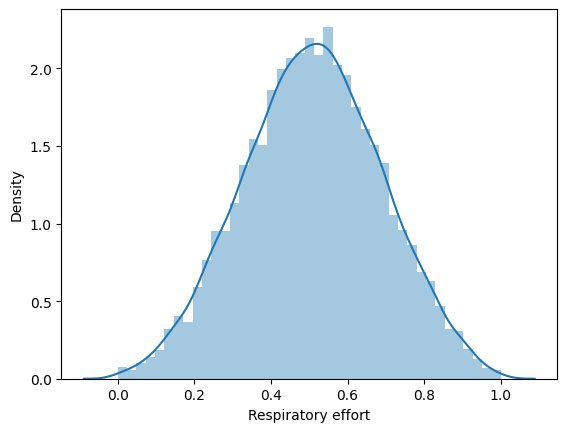

In [363]:
sns.distplot(tmp_tdata["Respiratory effort"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\704915687.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["O₂ extraction ratio"])


<Axes: xlabel='O₂ extraction ratio', ylabel='Density'>

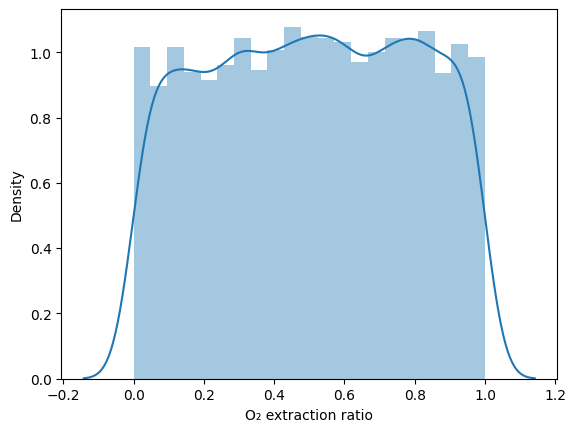

In [364]:
sns.distplot(tmp_tdata["O₂ extraction ratio"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2431346707.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["HR"])


<Axes: xlabel='HR', ylabel='Density'>

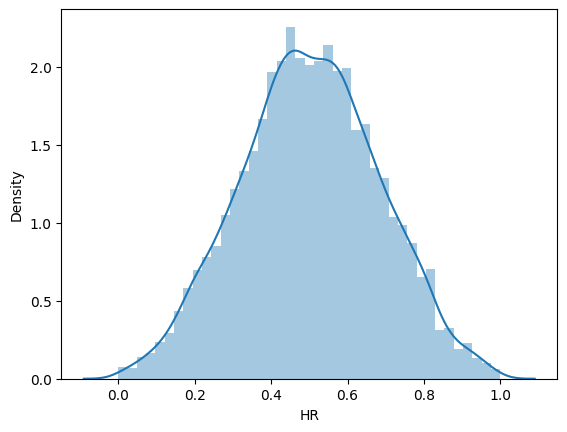

In [365]:
sns.distplot(tmp_tdata["HR"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3331703286.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["latitude"])


<Axes: xlabel='latitude', ylabel='Density'>

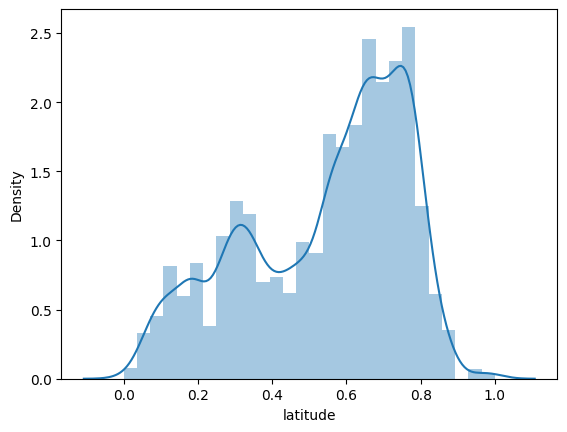

In [366]:
sns.distplot(tmp_tdata["latitude"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\462746292.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["longitude"])


<Axes: xlabel='longitude', ylabel='Density'>

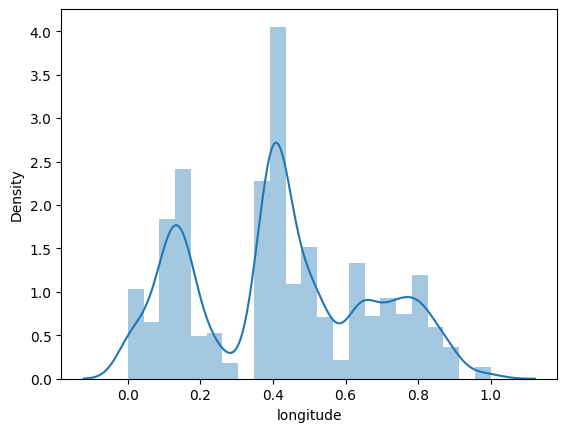

In [367]:
sns.distplot(tmp_tdata["longitude"])

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\3233047174.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tmp_tdata["BP"])


<Axes: xlabel='BP', ylabel='Density'>

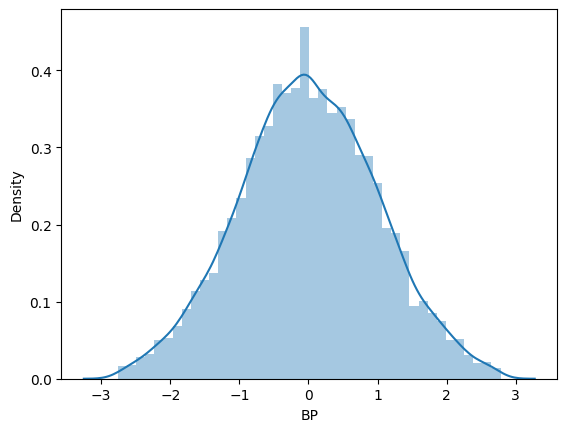

In [368]:
sns.distplot(tmp_tdata["BP"])

In [369]:
train_data = tmp_tdata
train_data

,PVI,Hb level,Skin Temperature,SpO₂,RR,FiO₂,Blood Flow Index,Respiratory effort,O₂ extraction ratio,HR,latitude,longitude,oximetry,BP
3642,0.465234,0.448770,0.546011,0.382161,0.553408,0.350167,0.494308,0.577737,0.308415,0.397201,0.599957,0.803494,1.0,0.367923
3643,0.757116,0.087280,0.197332,0.810504,0.750506,0.767547,0.848115,0.706626,0.041728,0.515569,0.682077,0.530468,1.0,-0.505095
3644,0.380747,0.714199,0.457617,0.484776,0.298189,0.342411,0.589996,0.565136,0.828372,0.584782,0.054889,1.000000,0.0,0.558724
3645,0.707474,0.638445,0.434814,0.465160,0.603467,0.920842,0.298612,0.517160,0.877289,0.732133,0.284139,0.185606,1.0,0.035746
3646,0.770623,0.560211,0.104833,0.502174,0.551962,0.315964,0.250299,0.515802,0.808440,0.196263,0.693978,0.397987,1.0,-2.017033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12130,0.629676,0.522289,0.417982,0.496990,0.491344,0.679920,0.666273,0.319943,0.167950,0.514560,0.340721,0.720048,0.0,-0.769710
12131,0.161192,0.864186,0.495728,0.387980,0.469008,0.442185,0.380684,0.556526,0.918293,0.009699,0.555016,0.098036,1.0,-1.866072
12132,0.574847,0.107633,0.510431,0.440563,0.648446,0.404766,0.367666,0.588653,0.114330,0.280117,0.162951,0.515455,1.0,1.619992
12133,0.419319,0.436420,0.588158,0.337159,0.589691,0.602278,0.551924,0.202003,0.500690,0.467236,0.708913,0.193202,1.0,-0.662076


In [370]:
for feature in train_data.columns:
    f_var = train_data[feature].var()
    f_uniq = train_data[feature].nunique()
    print(f"{feature} - {f_var:.3f}:{f_uniq}")

PVI - 0.029:8170
Hb level - 0.031:8107
Skin Temperature - 0.030:8168
SpO₂ - 0.028:8161
RR - 0.031:8167
FiO₂ - 0.032:8060
Blood Flow Index - 0.032:8170
Respiratory effort - 0.032:8170
O₂ extraction ratio - 0.082:8170
HR - 0.033:8113
latitude - 0.047:523
longitude - 0.060:522
oximetry - 0.242:2
BP - 1.000:8127


## Feature Selection

<h4>Let's use MI(Mutual Information) method to check entropy between all chosen features and the target variable. We're going to do so with aid of mutual information classifier for binary traget variable.</h4>

In [371]:
fs = train_data.drop("oximetry", axis = 1)

In [372]:
fmi_scorea = sklearn.feature_selection.mutual_info_classif(fs, train_data["oximetry"])
for score, name in zip(list(fmi_scorea), list(fs.columns)):
    print(f"Score:({score * 100:.2f}) & name:({name})")

Score:(4.77) & name:(PVI)
Score:(1.25) & name:(Hb level)
Score:(13.02) & name:(Skin Temperature)
Score:(5.12) & name:(SpO₂)
Score:(26.84) & name:(RR)
Score:(0.83) & name:(FiO₂)
Score:(0.58) & name:(Blood Flow Index)
Score:(0.13) & name:(Respiratory effort)
Score:(0.77) & name:(O₂ extraction ratio)
Score:(0.90) & name:(HR)
Score:(0.00) & name:(latitude)
Score:(0.00) & name:(longitude)
Score:(0.33) & name:(BP)


<h4>The features that bring at least some information are PVI, Hb level, Skin Temperature, SpO₂ and RR. The rest of the features practically don't have any information towards target variable.<br>
-----------------------------------------------------------------------------
<br>MI(Mutual Information):<br>
PVI<br>
Hb level<br>
Skin Temperature<br>
SpO₂<br>
RR
</p>
</h4>

<h4>Other 2 tests will be chi-squared test and f-statistic test. They will also likely help us to determine which of the attributes are valuable and which are not</h4>

In [373]:
chi_sq = sklearn.feature_selection.chi2
f_reg = sklearn.feature_selection.f_regression

In [374]:
clipped_fs = fs.drop(["longitude", "latitude", "BP"], axis = 1)

fcs_scorea = sklearn.feature_selection.SelectKBest(chi_sq, k = 5)
fcs_scorea.fit_transform(clipped_fs, train_data["oximetry"])
importance_fcs = getattr(fcs_scorea, "scores_", None)

freg_scorea = sklearn.feature_selection.SelectKBest(f_reg, k = 5)
freg_scorea.fit_transform(fs, train_data["oximetry"])
importance_freg = getattr(freg_scorea, "scores_", None)

print(clipped_fs.columns[fcs_scorea.get_support()])
print([int(sc) * 100 for sc in importance_fcs])
print("--------------------------------------------------------------------------")
print(fs.columns[freg_scorea.get_support()])
print([int(sc) * 100 for sc in importance_freg])

Index(['PVI', 'Hb level', 'Skin Temperature', 'SpO₂', 'RR'], dtype='object')
[300, 400, 8600, 3500, 24300, 0, 0, 0, 0, 0]
--------------------------------------------------------------------------
Index(['PVI', 'Hb level', 'Skin Temperature', 'SpO₂', 'RR'], dtype='object')
[7900, 6200, 142900, 65900, 612100, 0, 0, 200, 0, 100, 200, 0, 100]


<h4>
As can be seen from above the result from all 3 methods are identic, therefore we need to try a couple of other methods to find any features that weren't chosen by one of these methods.<br>
-----------------------------------------------------------------------------
<br>Chi-Sqaured Statistic and F-Statistic:<br>
PVI<br>
Hb level<br>
Skin Temperature<br>
SpO₂<br>
RR
</p>
</h4>

<h4>Let's choose our features based on performance of the model they will be fit in. The SVC(Support Vector Classifier) was chosen since it performs classification of categorical variables based on other independent attributes </h4>

In [375]:
logreg_estimator = sklearn.svm.SVC(kernel = "linear")
selector = sklearn.feature_selection.RFE(logreg_estimator, n_features_to_select = 5, step = 1)
selector = selector.fit(fs, train_data["oximetry"])
importance = getattr(selector, "ranking_", None)
print(importance)
print(fs.columns[selector.support_])

[5 1 1 1 1 1 2 8 3 4 9 7 6]
Index(['Hb level', 'Skin Temperature', 'SpO₂', 'RR', 'FiO₂'], dtype='object')


<h4>
This method shows us very familiar result to the previous 3 ones. The only change is that PVI has been substituted by FiO₂<br>
-----------------------------------------------------------------------------
<br>Chi-Sqaured Statistic and F-Statistic:<br>
SpO₂<br>
Hb level<br>
Skin Temperature<br>
FiO₂<br>
RR
</p>
</h4>

<h4>Linear SVC(Support Vector Classifier) is chosen to be used for attribute hunt(feature selection), but now we're using l1 penalty so attributes with small values are approximated to 0.</h4>

In [376]:

lsvc = sklearn.svm.LinearSVC(C = 0.01, penalty = "l1", dual = False).fit(fs, train_data["oximetry"])
lselector = sklearn.feature_selection.SelectFromModel(lsvc, prefit = True)
importance = np.abs(lsvc.coef_).ravel().argsort()[::-1]
print(fs.columns[lselector.get_support()])
# print(dir(lselector))
print(fs.columns[importance])

Index(['PVI', 'Hb level', 'Skin Temperature', 'SpO₂', 'RR', 'FiO₂',
       'O₂ extraction ratio', 'BP'],
      dtype='object')
Index(['RR', 'Skin Temperature', 'SpO₂', 'Hb level', 'PVI', 'FiO₂', 'BP',
       'O₂ extraction ratio', 'longitude', 'HR', 'latitude',
       'Respiratory effort', 'Blood Flow Index'],
      dtype='object')


<h4>
Current method yields not only all fields precedently extracted from preceding methods, but two more additional features<br>
-----------------------------------------------------------------------------
<br>Chi-Sqaured Statistic and F-Statistic:<br>
SpO₂<br>
Hb level<br>
Skin Temperature<br>
FiO₂<br>
RR<br>
O₂ extraction ratio<br>
BP<br>
</p>
</h4>

<h4>In the last method we will use Lasso Regression, since it works with linear models. Logistic Regression Model will be utilized for prediction of a binary variable. And since Logistic Regression is linear it falls into the required scope of models</h4>

In [377]:
lasso_model = sklearn.linear_model.Lasso(alpha=0.01).fit(fs, train_data["oximetry"])
lasso_selector = sklearn.feature_selection.SelectFromModel(lasso_model, prefit=True)
importance = getattr(lasso_model, "coef_")
print(fs.columns[lasso_selector.get_support()])
print(importance)

Index(['Skin Temperature', 'SpO₂', 'RR'], dtype='object')
[-0.         -0.          0.29697189  0.07628307  1.38929041 -0.
  0.         -0.         -0.          0.          0.          0.
  0.        ]


<h4>Hence the most significant features are ranked:<br>
1)RR<br>
2)Skin Temperature<br>
3)SpO₂<br>
4)Hb level<br>
The preceding features were chosen because they are present in all of the feature reduction attempts and are estimated to have the highest ranks among all other attributes in all tests.
</h4>


## Preprocessing Pipeline

<h4>We have made a manual pipeline without usage of sklearn.pipeline and a pipeline with usage of sklearn.pipeline. Also we have prepared a pipeline that cleans any new raw data in future datasets, and makes it ready for preprocessing pipeline, either manual or automatic to be used in.</h4>

In [378]:
flag_reuse = False
cols_params = dict.fromkeys(["PVI", "Hb level", "Skin Temperature", "SpO₂", "RR", "FiO₂", "Blood Flow Index", "Respiratory effort", "O₂ extraction ratio", "BP", "HR", "latitude", "longitude", "oximetry"])
pt_boxcox_g = None
pt_yejohn_g = None

def preprocess_data(preproc_data):
    global flag_reuse, cols_params, pt_boxcox_g, pt_yejohn_g
    #choose features
    preproc_cols = ["PVI", "Hb level", "Skin Temperature", "SpO₂", "RR", "FiO₂", "Blood Flow Index", "Respiratory effort", "O₂ extraction ratio", "BP", "HR", "latitude", "longitude", "oximetry"]
    
    chosen_features = preproc_data[preproc_cols]

    #transform features
    pt_boxcox = None
    pt_yejohn = None
    
    if (not flag_reuse):
        pt_boxcox = sklearn.preprocessing.PowerTransformer(method = "box-cox", standardize = False)
        pt_yejohn = sklearn.preprocessing.PowerTransformer(method = "yeo-johnson", standardize = False)
        
        pt_boxcox_g = pt_boxcox
        pt_yejohn_g = pt_yejohn
    else:
        pt_boxcox = pt_boxcox_g
        pt_yejohn = pt_yejohn_g

        
        

    bc_cols = chosen_features.drop(["BP", "longitude", "latitude", "oximetry"], inplace = False, axis = 1)
    yj_cols = chosen_features[["longitude", "latitude"]]
    if (not flag_reuse):
        chosen_features[bc_cols.columns] = pt_boxcox.fit_transform(bc_cols)
        chosen_features[yj_cols.columns] = pt_yejohn.fit_transform(yj_cols)
    else:
        chosen_features[bc_cols.columns] = pt_boxcox.transform(bc_cols)
        chosen_features[yj_cols.columns] = pt_yejohn.transform(yj_cols)

    columns_tNormalize = list(chosen_features.columns)
    columns_tNormalize.remove("BP")
    columns_tNormalize.remove("oximetry")

    #here we normalize datapoints that belong to non-normal distributions
    if (not flag_reuse):
        for column in columns_tNormalize:
            min_v = chosen_features[column].min()
            max_v = chosen_features[column].max()
            
            cols_params[column] = (max_v, min_v)
            chosen_features[column] = (chosen_features[column] - min_v) / (max_v - min_v)
    else:
        for column in columns_tNormalize:
            min_v = cols_params[column][1]
            max_v = cols_params[column][0]
            
            chosen_features[column] = (chosen_features[column] - min_v) / (max_v - min_v)

    #here we standardize points that belong to normal distribution
    bp_mean = None
    bp_std = None
    if (not flag_reuse):
        bp_mean = chosen_features["BP"].mean()
        bp_std = chosen_features["BP"].std()
        cols_params["BP"] = (bp_mean, bp_std)
    else:
        bp_mean = cols_params["BP"][0]
        bp_std = cols_params["BP"][1]
        
    chosen_features["BP"] = (chosen_features["BP"] - bp_mean) / bp_std
    #now we will choose 4 most important features
    chosen_features = chosen_features[["RR", "Skin Temperature", "SpO₂", "Hb level", "oximetry"]]
    if (not flag_reuse):
        flag_reuse = True
    return chosen_features

In [379]:
def fetch_pipeline():
    sklearn.set_config(transform_output = "pandas")
    #feature groups
    boxcox_cols = ["PVI", "Hb level", "Skin Temperature", "SpO₂", "RR", "FiO₂", "Blood Flow Index", "Respiratory effort", "O₂ extraction ratio"]
    yeojohn_cols = ["longitude", "latitude"]
    standard_cols = ["BP"]
    #feature selection step
    select_cols = ["RR", "Skin Temperature", "SpO₂", "Hb level", "oximetry"]

    preprocess_pipeline = sklearn.pipeline.Pipeline([
        ("modify_features", sklearn.compose.ColumnTransformer([
            ("bc_norm", sklearn.pipeline.Pipeline([("transf", sklearn.preprocessing.PowerTransformer(method = "box-cox", standardize = False)), ("norm", sklearn.preprocessing.MinMaxScaler())]), boxcox_cols),
            ("yj_norm", sklearn.pipeline.Pipeline([("transf", sklearn.preprocessing.PowerTransformer(method = "yeo-johnson", standardize = False)), ("norm", sklearn.preprocessing.MinMaxScaler())]), yeojohn_cols),
            ("bp_stand", sklearn.preprocessing.StandardScaler(), standard_cols)
            ], remainder = "passthrough", verbose_feature_names_out = False)
        ),
        ("select_features", sklearn.compose.ColumnTransformer([("cut", "passthrough", select_cols)], remainder = "drop", verbose_feature_names_out = False))
    ])

    return preprocess_pipeline


In [380]:
manual_traind = observations.iloc[int(len(observations) * 0.3) + 1:]
manual_testd = observations.iloc[:int(len(observations) * 0.3) + 1]

manual_traind

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
3642,96.905844,75.469415,9.463672,17.385070,39.426760,50.031003,145.959177,105.885253,36.464548,10.759696,...,4.023267,51.129836,50.472665,44.926490,53.083075,0.229383,33.843399,1.0,37.19723,122.05228
3643,98.648520,78.491861,8.840007,18.616369,38.605890,70.135347,106.065593,102.411841,34.819659,11.729405,...,4.044370,77.713870,27.753605,47.075223,61.297449,0.203896,34.429585,1.0,43.96222,43.63417
3644,97.334657,80.264415,10.101478,15.529219,38.975461,49.670694,119.938651,106.644383,36.099006,13.376519,...,4.064069,58.241938,60.760215,72.118808,52.283772,0.281887,26.053195,0.0,-38.65333,178.00417
3645,97.253262,84.050625,12.158790,17.711679,40.334182,77.840759,139.903764,104.563646,35.999939,11.475493,...,4.142042,36.806567,42.283811,36.279086,49.247146,0.287011,35.338933,1.0,8.35122,-62.64102
3646,97.406625,70.365475,12.089103,17.375483,40.286600,48.445969,98.358759,96.396397,34.262821,11.776894,...,4.007854,33.324337,49.250966,73.454658,49.161336,0.279808,29.303330,1.0,44.92801,4.89510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12130,97.385205,78.466039,13.349946,16.965079,39.771876,65.804506,125.231169,101.359033,35.925456,11.381142,...,4.043600,63.955049,62.704268,54.052104,36.885416,0.215833,37.802841,0.0,14.08230,98.19151
12131,96.930364,65.658406,11.212824,16.809527,38.855673,54.344864,127.384993,96.997014,36.260074,11.105850,...,4.002268,42.773740,58.200613,42.130057,51.738050,0.291330,21.791978,1.0,33.41012,-91.06177
12132,97.150812,72.491221,11.295314,17.996657,41.619844,52.582024,105.552984,110.866776,36.320781,9.961450,...,4.012385,41.823153,33.807926,54.432173,53.776058,0.210734,24.210105,1.0,-10.33333,39.28333
12133,96.715396,77.256318,15.914116,17.622823,39.353100,62.014037,116.798968,101.787271,36.629434,9.621106,...,4.033931,55.404543,20.146844,54.464593,29.602455,0.248375,20.018617,1.0,46.13510,-60.18310


In [381]:
preprocess_data(manual_traind)
processed_testd = preprocess_data(manual_testd)
processed_testd

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2441828070.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_features[bc_cols.columns] = pt_boxcox.fit_transform(bc_cols)
C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2441828070.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_features[yj_cols.columns] = pt_yejohn.fit_transform(yj_cols)
C:\Users\misha\AppData\Local\Temp\ipykernel_6280\2441828070.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

,RR,Skin Temperature,SpO₂,Hb level,oximetry
0,0.315678,0.379621,0.313651,0.339508,0.0
1,0.432803,0.584460,0.612396,0.505775,1.0
2,0.309354,0.458652,0.317536,0.545515,0.0
3,0.423394,0.659567,0.232346,0.583952,1.0
4,0.180962,0.251242,0.771873,0.592621,0.0
...,...,...,...,...,...
3637,0.149967,0.116198,0.606949,0.375169,0.0
3638,0.357649,0.356635,0.465723,0.476607,0.0
3639,0.208353,0.496965,0.295425,0.491944,0.0
3640,0.477883,0.586697,0.305593,0.582297,0.0


In [382]:
pipe = fetch_pipeline()
pipe_testd = observations.iloc[:int(len(observations) * 0.3) + 1]
pipe_traind = observations.iloc[int(len(observations) * 0.3) + 1:]

pipe_traind

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
3642,96.905844,75.469415,9.463672,17.385070,39.426760,50.031003,145.959177,105.885253,36.464548,10.759696,...,4.023267,51.129836,50.472665,44.926490,53.083075,0.229383,33.843399,1.0,37.19723,122.05228
3643,98.648520,78.491861,8.840007,18.616369,38.605890,70.135347,106.065593,102.411841,34.819659,11.729405,...,4.044370,77.713870,27.753605,47.075223,61.297449,0.203896,34.429585,1.0,43.96222,43.63417
3644,97.334657,80.264415,10.101478,15.529219,38.975461,49.670694,119.938651,106.644383,36.099006,13.376519,...,4.064069,58.241938,60.760215,72.118808,52.283772,0.281887,26.053195,0.0,-38.65333,178.00417
3645,97.253262,84.050625,12.158790,17.711679,40.334182,77.840759,139.903764,104.563646,35.999939,11.475493,...,4.142042,36.806567,42.283811,36.279086,49.247146,0.287011,35.338933,1.0,8.35122,-62.64102
3646,97.406625,70.365475,12.089103,17.375483,40.286600,48.445969,98.358759,96.396397,34.262821,11.776894,...,4.007854,33.324337,49.250966,73.454658,49.161336,0.279808,29.303330,1.0,44.92801,4.89510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12130,97.385205,78.466039,13.349946,16.965079,39.771876,65.804506,125.231169,101.359033,35.925456,11.381142,...,4.043600,63.955049,62.704268,54.052104,36.885416,0.215833,37.802841,0.0,14.08230,98.19151
12131,96.930364,65.658406,11.212824,16.809527,38.855673,54.344864,127.384993,96.997014,36.260074,11.105850,...,4.002268,42.773740,58.200613,42.130057,51.738050,0.291330,21.791978,1.0,33.41012,-91.06177
12132,97.150812,72.491221,11.295314,17.996657,41.619844,52.582024,105.552984,110.866776,36.320781,9.961450,...,4.012385,41.823153,33.807926,54.432173,53.776058,0.210734,24.210105,1.0,-10.33333,39.28333
12133,96.715396,77.256318,15.914116,17.622823,39.353100,62.014037,116.798968,101.787271,36.629434,9.621106,...,4.033931,55.404543,20.146844,54.464593,29.602455,0.248375,20.018617,1.0,46.13510,-60.18310


In [383]:
# Fit pipeline on training data
pipe.fit(pipe_traind)
pipe_testd = pipe.transform(pipe_testd)
pipe_testd

,RR,Skin Temperature,SpO₂,Hb level,oximetry
0,0.315678,0.379621,0.313651,0.339508,0.0
1,0.432803,0.584460,0.612396,0.505775,1.0
2,0.309354,0.458652,0.317536,0.545515,0.0
3,0.423394,0.659567,0.232346,0.583952,1.0
4,0.180962,0.251242,0.771873,0.592621,0.0
...,...,...,...,...,...
3637,0.149967,0.116198,0.606949,0.375169,0.0
3638,0.357649,0.356635,0.465723,0.476607,0.0
3639,0.208353,0.496965,0.295425,0.491944,0.0
3640,0.477883,0.586697,0.305593,0.582297,0.0


<h4>Also before using pipeline built earlier, to clean the data, function preclean_data can be used. Any new data uploaded can be cleaned in the right manner, using that function and then later passed safely into the pipeline, so no problems would arise with it because of uncleaned data. </h4>

In [384]:
observations_cpy

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,96.615321,66.240820,10.877068,15.668587,39.658243,68.389223,96.163913,100.816532,35.751151,12.129743,...,4.002266,47.010676,54.479165,41.743618,50.708816,0.259091,39.107576,0.0,53.60520,10.03988
1,97.857755,71.825379,8.921403,16.552066,40.874901,44.950264,120.131860,93.114821,36.615192,10.568549,...,4.010066,57.466919,42.151782,40.852335,36.853826,0.240683,25.113412,1.0,43.78956,7.60872
2,96.631890,92.036880,12.541174,15.618439,41.920327,56.997064,169.416508,106.999465,36.103454,10.990277,...,4.758854,50.900908,67.493365,25.994388,54.595833,0.296654,39.118661,0.0,-30.60106,-71.19901
3,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,4.123592,34.585783,64.340739,52.661503,52.678544,0.234541,21.987564,1.0,51.26000,-2.18750
4,98.496281,82.390453,16.397518,14.534631,39.147657,60.595273,94.984050,104.124699,35.115265,11.262360,...,4.100501,75.665416,45.108028,58.489321,54.935624,0.267257,34.891072,0.0,26.11527,86.59509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12130,97.385205,78.466039,13.349946,16.965079,39.771876,65.804506,125.231169,101.359033,35.925456,11.381142,...,4.043600,63.955049,62.704268,54.052104,36.885416,0.215833,37.802841,0.0,14.08230,98.19151
12131,96.930364,65.658406,11.212824,16.809527,38.855673,54.344864,127.384993,96.997014,36.260074,11.105850,...,4.002268,42.773740,58.200613,42.130057,51.738050,0.291330,21.791978,1.0,33.41012,-91.06177
12132,97.150812,72.491221,11.295314,17.996657,41.619844,52.582024,105.552984,110.866776,36.320781,9.961450,...,4.012385,41.823153,33.807926,54.432173,53.776058,0.210734,24.210105,1.0,-10.33333,39.28333
12133,96.715396,77.256318,15.914116,17.622823,39.353100,62.014037,116.798968,101.787271,36.629434,9.621106,...,4.033931,55.404543,20.146844,54.464593,29.602455,0.248375,20.018617,1.0,46.13510,-60.18310


In [385]:
preclean_data(observations_cpy)
observations_cpy

C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)
C:\Users\misha\AppData\Local\Temp\ipykernel_6280\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,96.615321,66.240820,10.877068,15.668587,39.658243,68.389223,96.163913,100.816532,35.751151,12.129743,...,4.002266,47.010676,54.479165,41.743618,50.708816,0.259091,39.107576,0.0,53.60520,10.03988
3,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,4.123592,34.585783,64.340739,52.661503,52.678544,0.234541,21.987564,1.0,51.26000,-2.18750
4,98.496281,82.390453,16.397518,14.534631,39.147657,60.595273,94.984050,104.124699,35.115265,11.262360,...,4.100501,75.665416,45.108028,58.489321,54.935624,0.267257,34.891072,0.0,26.11527,86.59509
5,96.330910,76.617920,10.412687,16.889530,41.355032,57.741858,114.410769,104.707593,36.396458,11.336398,...,4.029392,63.262210,68.080618,48.121800,63.196636,0.233605,39.991586,1.0,25.66795,85.83636
7,98.463297,72.878802,12.763392,18.037806,39.886221,50.664259,95.064514,99.241748,34.899798,12.360385,...,4.013478,51.518070,65.835808,56.801196,53.196426,0.262041,26.167014,1.0,29.84576,-90.10674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12130,97.385205,78.466039,13.349946,16.965079,39.771876,65.804506,125.231169,101.359033,35.925456,11.381142,...,4.043600,63.955049,62.704268,54.052104,36.885416,0.215833,37.802841,0.0,14.08230,98.19151
12131,96.930364,65.658406,11.212824,16.809527,38.855673,54.344864,127.384993,96.997014,36.260074,11.105850,...,4.002268,42.773740,58.200613,42.130057,51.738050,0.291330,21.791978,1.0,33.41012,-91.06177
12132,97.150812,72.491221,11.295314,17.996657,41.619844,52.582024,105.552984,110.866776,36.320781,9.961450,...,4.012385,41.823153,33.807926,54.432173,53.776058,0.210734,24.210105,1.0,-10.33333,39.28333
12133,96.715396,77.256318,15.914116,17.622823,39.353100,62.014037,116.798968,101.787271,36.629434,9.621106,...,4.033931,55.404543,20.146844,54.464593,29.602455,0.248375,20.018617,1.0,46.13510,-60.18310


# Machine Learning

### Data Preprocession and Function Definition 

In [386]:
test_mld = observations.iloc[:int(len(observations) * 0.25) + 1]
train_mld = observations.iloc[int(len(observations) * 0.25) + 1 : int(len(observations) * 0.8) + 1]
valid_mld = observations.iloc[int(len(observations) * 0.8) + 1:]

In [387]:
ppcd_train = pipe.fit_transform(train_mld)
ppcd_valid = pipe.transform(valid_mld)
ppcd_test = pipe.transform(test_mld)


In [398]:
#[node_id] = (threshold, left_child, right_child, node_name)
def classify(tree, root, record):
    curr_node = root
    while True:
        if curr_node in (0, 1): 
            return curr_node
        
        node = tree[curr_node]
        
        if(record[node[3]] > node[0]): #if record's value is more than threshold than move to the right child
            curr_node = node[2]
        else: #otherwise move to the left one
            curr_node = node[1]
        
        

In [399]:
def estimate_performance(dataset, ares, model_type, model=None, root=None):
    TP, TN, FP, FN = 0, 0, 0, 0

    if ares:
        series = pd.Series(index = range(len(dataset)), dtype = int)

    for i in range(len(dataset)):
        record = dataset.iloc[i, :]

        if model_type == "ID3":
            res = classify(model, root, record)

        elif model_type == "Forest":
            pred_rec = record.drop("oximetry")
            res = model.predict(pd.DataFrame([pred_rec]))[0]
        elif model_type == "LogInt":
            pred_rec = record.drop("oximetry")
            res = model.predict(pd.DataFrame([pred_rec]))[0]

        if res == record["oximetry"]:
            if res == 1:
                TP += 1
            else:
                TN += 1
        else:
            if res == 1:
                FP += 1
            else:
                FN += 1

        if ares:
            series.iat[i] = res 

    if ares:
        dataset["pr_oximetry"] = series

    accuracy = ((TP + TN) / (TP + TN + FP + FN)) * 100
    precision_pos = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0
    precision_neg = (TN / (TN + FN)) * 100 if (TN + FN) > 0 else 0
    recall_pos = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0
    recall_neg = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0
    f1 = (2 * precision_pos * recall_pos / (precision_pos + recall_pos)) if (precision_pos + recall_pos) > 0 else 0

    ones = dataset["oximetry"].mean()
    zeros = 1 - ones

    return accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros


## Model Evaluation

### ID3 Dichotomizer

In [400]:
def compute_entropy(subset, prime_attr):
    p1 = subset[prime_attr].mean()
    p2 = 1 - p1
    
    if((p1 == 0) or (p2 == 0)): return 0
    
    entr = p1*math.log2(1/p1) + p2*math.log2(1/p2)
    return entr
    

In [401]:
def find_best_IG(attr, subset, target_attr, parent_entr, max_sd):
    new_sub = subset[[attr, target_attr]].copy()
    new_sub.sort_values(by = [attr], axis = 0, inplace = True)
    
    
    threshold = 0
    curr_IG = 0
    for v_ind in range(len(new_sub) - 1):
        if(new_sub[target_attr].iloc[v_ind] != new_sub[target_attr].iloc[v_ind + 1]):
            t = (new_sub[attr].iloc[v_ind + 1] + new_sub[attr].iloc[v_ind]) / 2
            
            sub1 = subset[subset[attr] > t].copy()
            sub2 = subset[subset[attr] <= t].copy()
            
            if((len(sub1) == 0) or (len(sub2) == 0)): continue
            if((len(sub1)/len(sub2) >= max_sd) or (len(sub2)/len(sub1) >= max_sd)): continue
                
            
            s1_entr = compute_entropy(sub1, target_attr)
            s2_entr = compute_entropy(sub2, target_attr)
            new_entr = (len(sub1)/len(subset))*s1_entr + (len(sub2)/len(subset))*s2_entr
            new_IG = parent_entr - new_entr
            # min_IG = 1e-2 # tune
            if(new_IG > curr_IG):
                threshold = t
                curr_IG = new_IG
                  
    return curr_IG, threshold 


In [402]:
max_sd = 1.05 #maximum size difference between subsets
size_thr = 50 #minimum size of the node, below which it's not divided further

ID3_tree = {}
root = None
NODE_COUNTER = -1
avail_attr = list(ppcd_train.columns)
avail_attr.remove("oximetry")

<h4>The implemented dichotomizer is pruned during build-time. <br>
The sizes of subsets are balanced throughout selection of thresholds for each of the attributes, therefore thresholds aren't extremely large or tiny. And since they're not extremely large or tiny most of the predicted samples do not fall into one of the children's dataset.</h4>

In [403]:
def ID3_classify(subset, target_attr, avail_attr):
    global root, ID3_tree, NODE_COUNTER, size_thr, max_sd
    
    parent_entr = compute_entropy(subset, target_attr)
    best_attr = tuple()
    targeted_series = subset[target_attr]
    
    if(targeted_series.nunique() == 1): #if a subset is homogeneous than we return the representative value
       return targeted_series.iat[0]
    elif(len(avail_attr) == 0): #if we don't have any attributes left we return the value with the biggest number of occurences, vedilicet 1 or 0
        majority_class = 1 if ((subset[target_attr] == 1).sum() > (subset[target_attr] == 0).sum()) else 0
        return majority_class
    
    for attr in avail_attr:
        IG_val, thr = find_best_IG(attr, subset, target_attr, parent_entr, max_sd) #computing the smallest entropy and threshold for the current attribute, hence the attribute with biggest IG  
        if((len(best_attr) == 0) or (IG_val > best_attr[1])): #at the beginning best_attr is empty so we need to fill it, so later we have something to compare our computed entropies to
            best_attr = (attr, IG_val, thr)
        
    new_attr = avail_attr.copy()
    new_attr.remove(best_attr[0]) #removing chosen attribute so children wouldn't be able to select it
        
    node_id = NODE_COUNTER #Since NODE_COUNTER's initial value is -1, 0 and 1 values can't be ID numbers
    NODE_COUNTER -= 1 #And to make sure that values of NIL nodes are not confused for IDs of internal nodes, their IDs would be negative
    
    rc_subset = subset[subset[best_attr[0]] > best_attr[2]].copy() #right child's subset
    lc_subset = subset[subset[best_attr[0]] <= best_attr[2]].copy() #left child's subset
    
    #majority_class for right child
    if (len(rc_subset) < size_thr):
        leaf_vr = 1 if((rc_subset[target_attr] == 1).sum() > (rc_subset[target_attr] == 0).sum()) else 0
        right_child = leaf_vr
    else:
        right_child = ID3_classify(rc_subset, target_attr, new_attr)
        
    
    
    #majority_class for left child
    if(len(lc_subset) < size_thr):
        leaf_vl = 1 if((lc_subset[target_attr] == 1).sum() > (lc_subset[target_attr] == 0).sum()) else 0
        left_child = leaf_vl
    else:
        left_child = ID3_classify(lc_subset, target_attr, new_attr)
        
    ID3_tree[node_id] = (best_attr[2], left_child, right_child, best_attr[0])
    # print(f"Best split on {best_attr[0]} at {best_attr[2]} -> left: {len(lc_subset)}, right: {len(rc_subset)}")

    
    return node_id #if a child is not NIL, i.e. not 0 or 1 then we need to return it's name so parent puts that name into his record inside of ID3_tree
    



In [404]:
root = ID3_classify(ppcd_train, "oximetry", avail_attr)


In [405]:
for key in sorted(list(ID3_tree.keys()), reverse = True):
    print(f"{key} : {ID3_tree[key]}", end = "\n")
    

-1 : (np.float64(0.4466780155947078), -9, -2, 'RR')
-2 : (np.float64(0.5123843238677435), -6, -3, 'Skin Temperature')
-3 : (np.float64(0.48447038777003637), -5, -4, 'Hb level')
-4 : (0, 0, 1, 'SpO₂')
-5 : (0, 0, 1, 'SpO₂')
-6 : (np.float64(0.5790988735766667), -8, -7, 'SpO₂')
-7 : (np.float64(0.47637580969520577), 1, 1, 'Hb level')
-8 : (np.float64(0.4261179048937268), 1, 1, 'Hb level')
-9 : (np.float64(0.36581755626847223), -13, -10, 'Skin Temperature')
-10 : (np.float64(0.4143874680294095), -12, -11, 'SpO₂')
-11 : (np.float64(0.44213746051195013), 1, 1, 'Hb level')
-12 : (np.float64(0.47265613577142496), 0, 0, 'Hb level')
-13 : (np.float64(0.4972584065987796), -15, -14, 'Hb level')
-14 : (np.float64(0.5320604929185584), 0, 0, 'SpO₂')
-15 : (np.float64(0.3590000864057279), 0, 0, 'SpO₂')


<h4>Let's check performance of our model on train data. As it can be seen there aren't any abnormally high results for our training data.</h4>

In [406]:
accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_train, ares = False, model_type = "ID3", model = ID3_tree, root = root)

print("ID3 Dichotomizer(Training Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

ID3 Dichotomizer(Training Dataset)
Accuracy: 82.00 %
Precision(1): 83.11%
Precision(0): 80.17%
Recall(1): 87.39%
Recall(0): 74.17%
F1-score: 85.20%
------------------
1: 59.26040061633282;
0: 40.73959938366718


<h4>The following metrics from our ID3 classificator with pruning were measured. As can be seen the F1-score is moderately high.</h4>

In [407]:
accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_valid, ares = False, model_type = "ID3", model = ID3_tree, root = root)

print("ID3 Dichotomizer(Validation Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

ID3 Dichotomizer(Validation Dataset)
Accuracy: 83.43 %
Precision(1): 84.26%
Precision(0): 81.94%
Recall(1): 89.28%
Recall(0): 74.46%
F1-score: 86.70%
------------------
1: 60.49173378550233;
0: 39.50826621449767


### Random Forest

<h4>Let's train another tree model on our training data to compare its metrics with our manually-implemented classificator. The tree model chosen for comparison is Random Forest</h4>

In [408]:
#model without tuned parameters
RandomForest = sklearn.ensemble.RandomForestClassifier(n_estimators = 30, min_samples_leaf = 4, min_samples_split = 8)
RandomForest.fit(ppcd_train.drop("oximetry", axis = 1), ppcd_train["oximetry"])


,n_estimators,30
,criterion,'gini'
,max_depth,None
,min_samples_split,8
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<h4>Neither this model has any abnormally high results for our training data in comparison to training data.</h4>

In [409]:
accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_train, ares = False, model_type = "Forest", model = RandomForest, root = None)

print("Random Forest(Training Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")    
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

Random Forest(Training Dataset)
Accuracy: 94.22 %
Precision(1): 95.54%
Precision(0): 92.35%
Recall(1): 94.67%
Recall(0): 93.57%
F1-score: 95.10%
------------------
1: 59.26040061633282;
0: 40.73959938366718


<h4>As can be seen from the current example this model performs overall better than our dichotomizer, yet only slightly better.</h4>

In [410]:
accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_valid, ares = False, model_type = "Forest", model = RandomForest, root = None)

print("Random Forest(Validation Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")    
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

Random Forest(Validation Dataset)
Accuracy: 87.92 %
Precision(1): 90.67%
Precision(0): 83.87%
Recall(1): 89.21%
Recall(0): 85.94%
F1-score: 89.93%
------------------
1: 60.49173378550233;
0: 39.50826621449767


### Logistic Regression

<h4>Now let's try another model belonging to non-linear class. The selected model is Logistic Regression.</h4>

In [411]:
#model without tuned parameters
LogisticRegression = sklearn.linear_model.LogisticRegression(penalty = "l2", max_iter = 100, class_weight = "balanced", solver = "sag", C = 0.1)
LogisticRegression.fit(ppcd_train.drop("oximetry", axis = 1), ppcd_train["oximetry"])


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


<h4>Let's check this model for overfitting also.</h4>

In [412]:
accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_train, ares = False, model_type = "LogInt", model = LogisticRegression, root = None)

print("Logistic Regression(Validation Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

Logistic Regression(Validation Dataset)
Accuracy: 82.77 %
Precision(1): 88.90%
Precision(0): 75.57%
Recall(1): 81.05%
Recall(0): 85.29%
F1-score: 84.79%
------------------
1: 59.26040061633282;
0: 40.73959938366718


In [413]:
accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_valid, ares = False, model_type = "LogInt", model = LogisticRegression, root = None)

print("Logistic Regression(Validation Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

Logistic Regression(Validation Dataset)
Accuracy: 83.76 %
Precision(1): 90.22%
Precision(0): 75.87%
Recall(1): 82.06%
Recall(0): 86.37%
F1-score: 85.94%
------------------
1: 60.49173378550233;
0: 39.50826621449767


### Visualization

<h4>In order to understand how the trees are build a visualization is made to Random Forest's first tree, videlicet we will visualize the tree</h4>

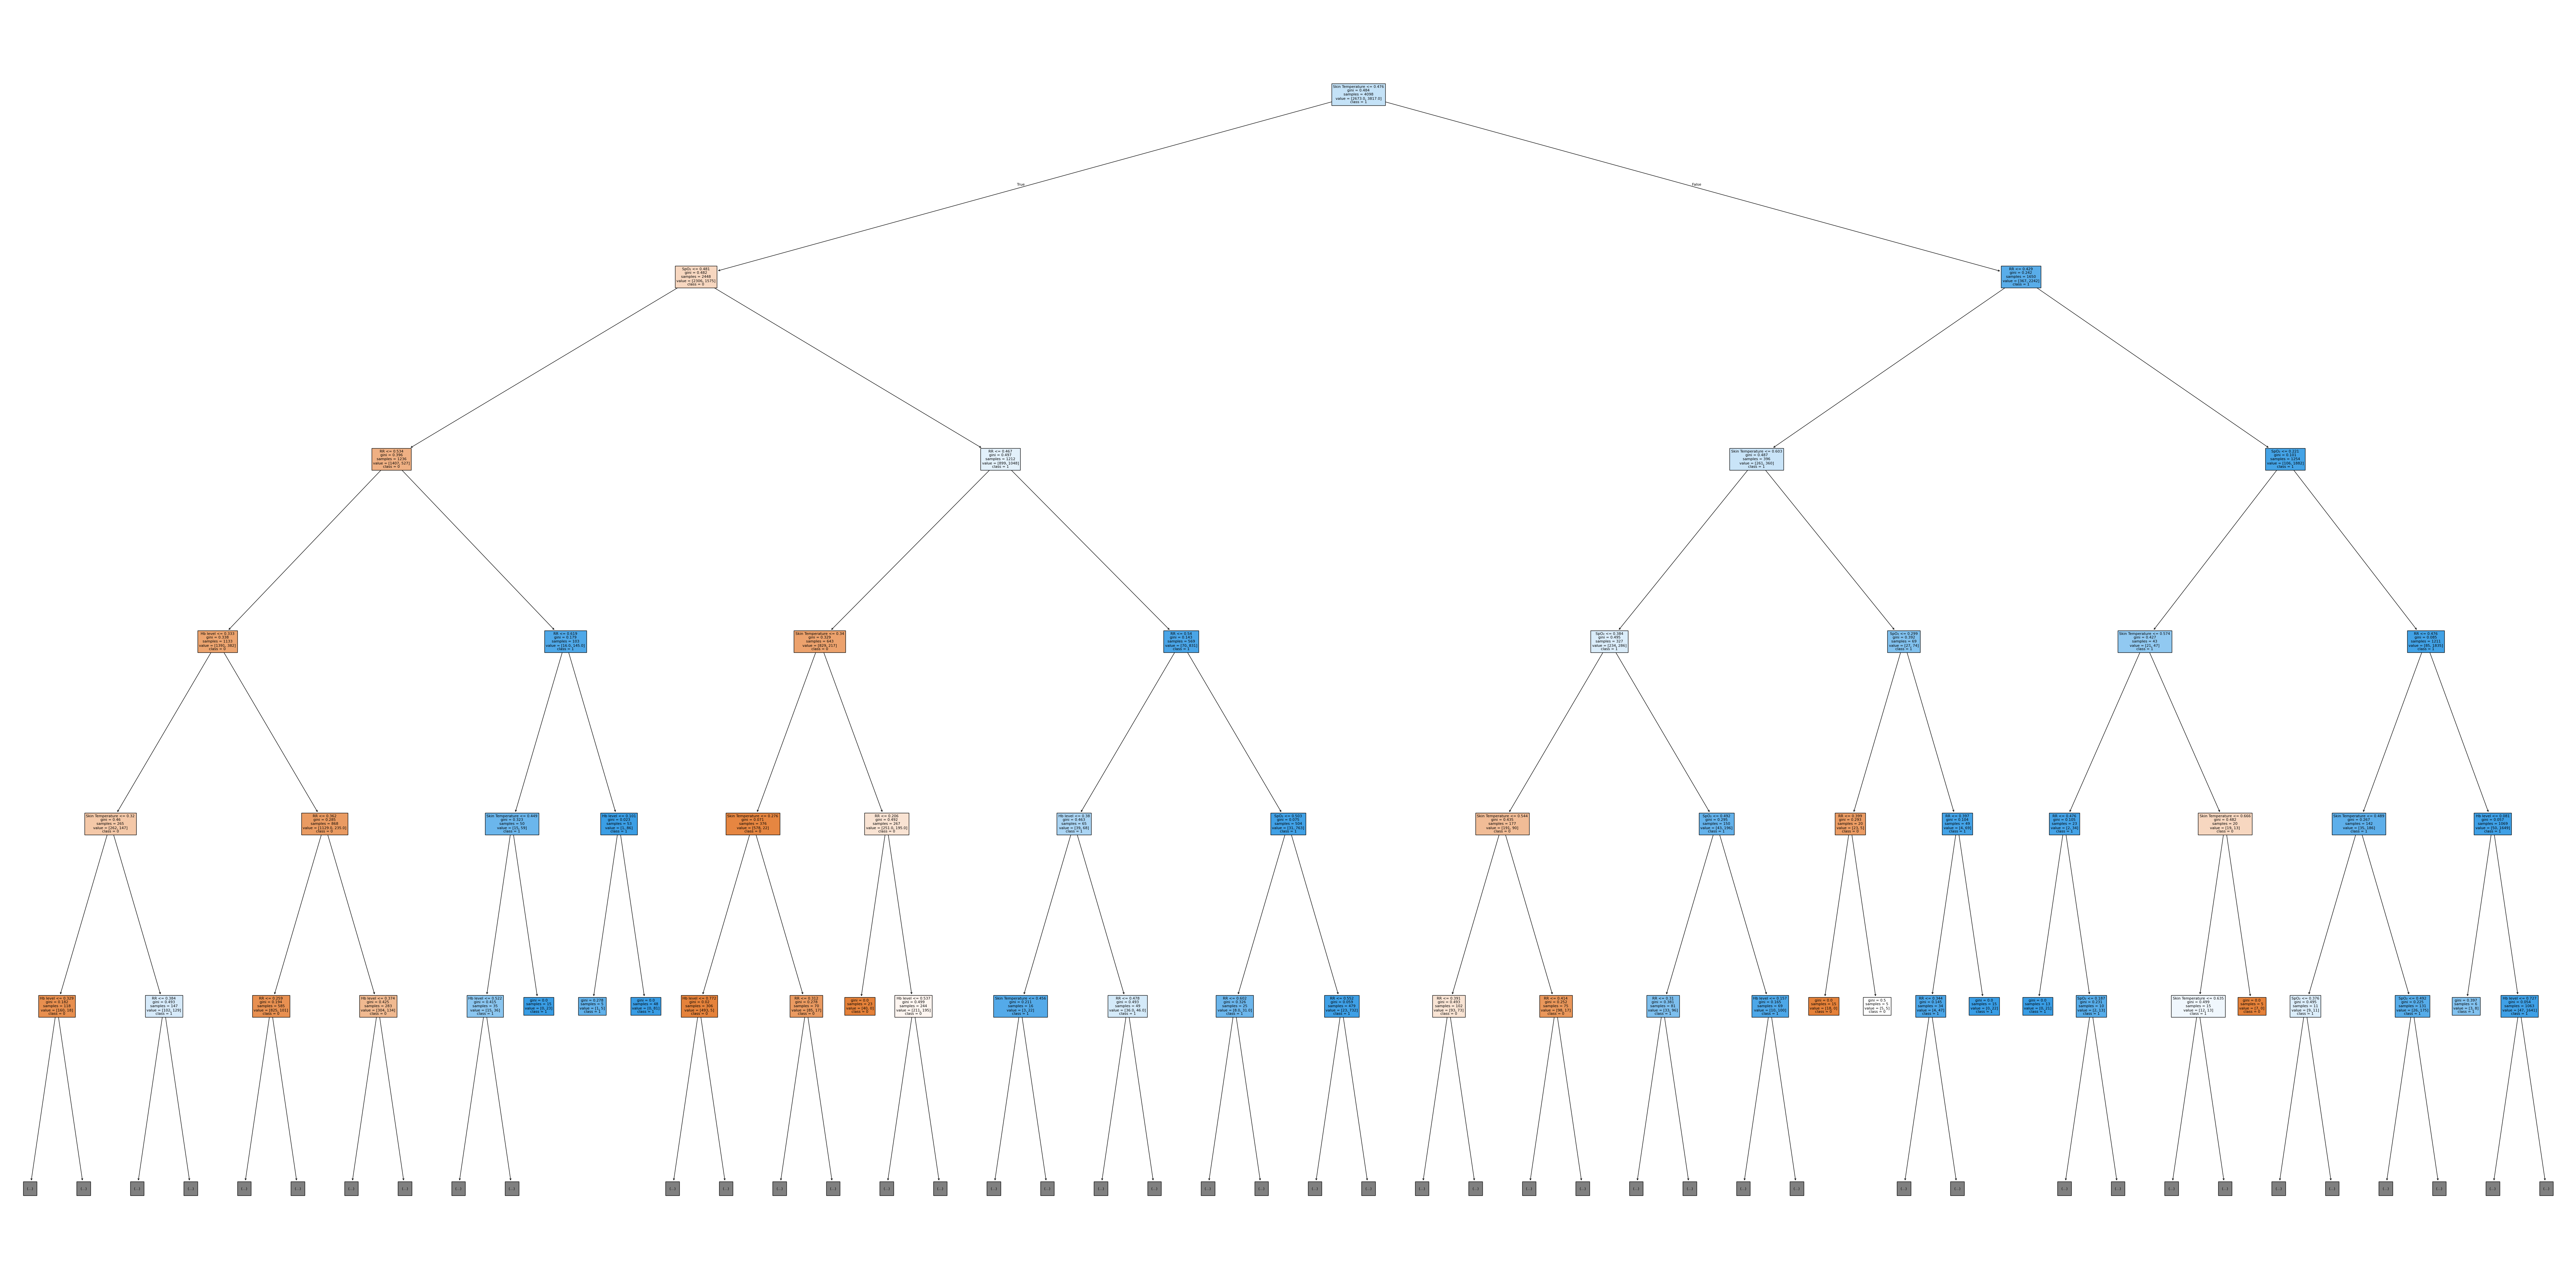

In [414]:
plt.figure(figsize = (100, 50))
sklearn.tree.plot_tree(RandomForest.estimators_[1], feature_names = ppcd_train.drop("oximetry", axis = 1).columns, class_names = ["0", "1"], filled = True, max_depth = 5)
plt.show()

<h3>The most performant model so far is Random Forest, and the second most effective is ID3 Dichotomizer</h3>

## Hyperparameter Tuning and Model Selection

### Hyperparameter Tuning

<h4>Now let's tune our models so they get the highest performance. And thus model with the highest performance would be gleaned out to use for deployment.</h4>

In [415]:
#hyperparameter tuning
param_grid = {
    "n_estimators": [50, 60],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [5, 10, 20],
}

grid = sklearn.model_selection.GridSearchCV(
    sklearn.ensemble.RandomForestClassifier(),
    param_grid,
    cv = 7,
    scoring = "f1",
    n_jobs = -1
)

grid.fit(ppcd_train.drop("oximetry", axis = 1), ppcd_train["oximetry"])

print(grid.best_params_)
best_model = grid.best_estimator_

{'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 60}


In [416]:
#hyperparameter tuning

param_grid = {
    "penalty": ["l2", "l1", "elasticnet"],
    "max_iter": [100, 200, 500],
    "class_weight": ["balanced"],
    "solver": ["liblinear"],
    "C" : [1.0, 0.75, 0.5, 0.25, 0.1, 0.07]
}

grid = sklearn.model_selection.GridSearchCV(
    sklearn.linear_model.LogisticRegression(),
    param_grid,
    cv = 5,
    scoring = "f1",
    n_jobs = -1
)

grid.fit(ppcd_train.drop("oximetry", axis = 1), ppcd_train["oximetry"])

print(grid.best_params_)
best_model = grid.best_estimator_

LogisticRegression = sklearn.linear_model.LogisticRegression(penalty = "l2", max_iter = 500, class_weight = "balanced", solver = "sag", C = 1.0)
LogisticRegression.fit(ppcd_train.drop("oximetry", axis = 1), ppcd_train["oximetry"])


{'C': 0.5, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}


c:\Users\misha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
90 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\misha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\misha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\misha\AppData\Local\Programs\Python\Python310\lib\site-packag

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'sag'
,max_iter,500
,multi_class,'deprecated'


<h4>Now let's check parameters of tuned models and select the most performant one</h4>

### Random Forest

In [423]:
#model with tuned parameters
RandomForest = sklearn.ensemble.RandomForestClassifier(n_estimators = 60, min_samples_leaf = 10, min_samples_split = 2)
RandomForest.fit(ppcd_train.drop("oximetry", axis = 1), ppcd_train["oximetry"])


accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_train, ares = False, model_type = "Forest", model = RandomForest, root = None)

print("Random Forest(Training Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")    
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

print ("\n=================================\n")
accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_valid, ares = False, model_type = "Forest", model = RandomForest, root = None)

print("Random Forest(Validation Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")    
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

Random Forest(Training Dataset)
Accuracy: 90.76 %
Precision(1): 93.26%
Precision(0): 87.33%
Recall(1): 90.98%
Recall(0): 90.43%
F1-score: 92.10%
------------------
1: 59.26040061633282;
0: 40.73959938366718


Random Forest(Validation Dataset)
Accuracy: 87.54 %
Precision(1): 90.67%
Precision(0): 83.02%
Recall(1): 88.51%
Recall(0): 86.05%
F1-score: 89.57%
------------------
1: 60.49173378550233;
0: 39.50826621449767


### Logistic Regression

In [421]:
#model with tuned parameters
LogisticRegression = sklearn.linear_model.LogisticRegression(penalty = "l1", max_iter = 100, class_weight = "balanced", solver = "liblinear", C = 0.5)
LogisticRegression.fit(ppcd_train.drop("oximetry", axis = 1), ppcd_train["oximetry"])

accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_train, ares = False, model_type = "LogInt", model = LogisticRegression, root = None)

print("Logistic Regression(Validation Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")


print ("\n=================================\n")


accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_valid, ares = False, model_type = "LogInt", model = LogisticRegression, root = None)

print("Logistic Regression(Training Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

Logistic Regression(Validation Dataset)
Accuracy: 82.74 %
Precision(1): 88.61%
Precision(0): 75.74%
Recall(1): 81.33%
Recall(0): 84.80%
F1-score: 84.82%
------------------
1: 59.26040061633282;
0: 40.73959938366718


Logistic Regression(Training Dataset)
Accuracy: 83.85 %
Precision(1): 89.68%
Precision(0): 76.46%
Recall(1): 82.83%
Recall(0): 85.41%
F1-score: 86.12%
------------------
1: 60.49173378550233;
0: 39.50826621449767


### ID3 Dichotomizer

In [419]:
accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_train, ares = False, model_type = "ID3", model = ID3_tree, root = root)

print("ID3 Dichotomizer(Training Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")


print ("\n=================================\n")


accuracy, precision_pos, precision_neg, recall_pos, recall_neg, f1, ones, zeros = estimate_performance(dataset = ppcd_valid, ares = False, model_type = "ID3", model = ID3_tree, root = root)

print("ID3 Dichotomizer(Validation Dataset)")
print(f"Accuracy: {accuracy:.2f} %") 
print(f"Precision(1): {precision_pos:.2f}%")
print(f"Precision(0): {precision_neg:.2f}%")
print(f"Recall(1): {recall_pos:.2f}%")
print(f"Recall(0): {recall_neg:.2f}%")
print(f"F1-score: {f1:.2f}%")

print("------------------")
print(f"1: {ones * 100};\n0: {zeros * 100}")

ID3 Dichotomizer(Training Dataset)
Accuracy: 82.00 %
Precision(1): 83.11%
Precision(0): 80.17%
Recall(1): 87.39%
Recall(0): 74.17%
F1-score: 85.20%
------------------
1: 59.26040061633282;
0: 40.73959938366718


ID3 Dichotomizer(Validation Dataset)
Accuracy: 83.43 %
Precision(1): 84.26%
Precision(0): 81.94%
Recall(1): 89.28%
Recall(0): 74.46%
F1-score: 86.70%
------------------
1: 60.49173378550233;
0: 39.50826621449767


<h4>Random Forest is the most performant model. The difference between validation dataset F1-score and training dataset F1-score is 3% at most. That is considered no-overfit to small-overfit result. In order to further prove the fact that there's no overfit let's visualize dataset sizes and their f1-scores.</h4>

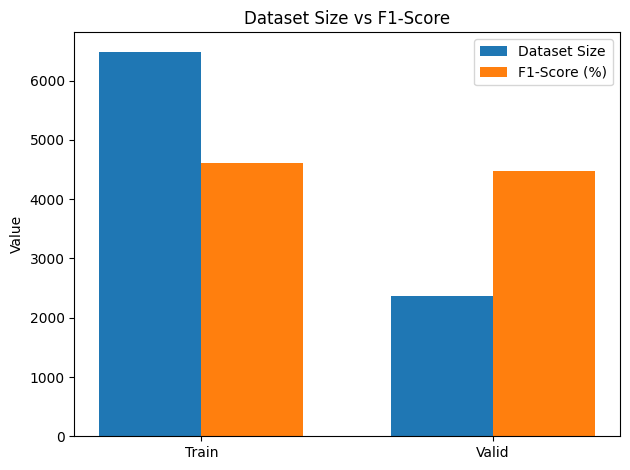

In [428]:
values_d = [len(ppcd_train), len(ppcd_valid)]
values_s = [92.10 * 50, 89.57 * 50]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, values_d, width, label="Dataset Size")
plt.bar(x + width/2, values_s, width, label="F1-Score (%)")

plt.xticks(x, labels)
plt.ylabel("Value")
plt.title("Dataset Size vs F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

<h4>As can be seen difference between f1-score of the training dataset doesn't vary dreastically from f1-score of validation dataset, therefore we can draw the conclusion that the model isn't overfitted</h4>